# ДЗ №2. Отбор кандидатов


Общая информация
Дата выдачи: 3 февраля 2026

Дедлайн: 23 февраля 2026 23:59 MSK


В этом и последующих домашних заданиях мы построим приближенную к реальной рекомендательную систему. Работать будем с данными marketplace из [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD).

Обычно рекомендательная система состоит из нескольких этапов:
1. Отбор кандидатов (Retrieval)
2. Ранжирование (Ranking)
3. Бизнес-логика (например, условие на то, чтобы товары от одного продавца не стояли в ленте друг за другом)

В этом домашнем задании сосредоточимся на первом этапе.

По ресурсам: at worst нужно 15GB RAM и 3.5GB свободного дискового пространства, GPU не требуется (но можно, если хочется). Дз спокойно запускается на ресурсах Kaggle-а.

In [3]:
!pip install -q polars huggingface_hub implicit faiss-cpu torch


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import glob
import os
import random
import time
import gc
from abc import ABC, abstractmethod
from collections import defaultdict, deque
from math import log2

import faiss
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from implicit.als import AlternatingLeastSquares
from implicit.ann.faiss import FaissModel
from IPython.display import HTML
from scipy.sparse import coo_matrix, csr_matrix
from torch.utils.data import DataLoader, Dataset, IterableDataset
from tqdm.notebook import tqdm



from collections import Counter
import itertools

## Download Data

Данные занимают около 3.5 GB

In [5]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    local_dir=".",
    local_dir_use_symlinks=False,
    allow_patterns=["dataset/small/users.pq", "dataset/small/marketplace/**"]
)

Fetching ... files: 0it [00:00, ?it/s]

'/Users/admin/Desktop/AI/REC_HSE/HW'

## EDA (1p)

Изучите данные (users, items, events). Для работы используйте polars - это более оптимизированный аналог pandas. Обратите внимание, что в polars существуют eager и lazy методы работы с таблицами, и зачастую эффективнее использовать lazy.

1. Оцените количество строк и столбцов в таблицах
2. Для всех категориальных переменных рассчитайте частотность каждого признака и процент null-ов. Удобно вывести результат в виде таблицы с помощью следующего кода: `HTML(polars_df.to_pandas().to_html())` - так не нужно будет задумываться про `display.max_rows`
3. Постройте гистограмму для числовых переменных, также оцените процент null-ов
4. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество уникальных пользователей и айтемов за этот день
5. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество событий в разбивке по `action_type`
6. Кликаутят (переходят на сайт партнера) ли люди один и тот же товар несколько раз?
7. Опционально любая другая аналитика на ваше усмотрение (например, можно покластеризовать эмбеддинги товаров и сравнить пересечения кластеров с категориями)

In [6]:
# uppercase для global переменных, чтобы легче видеть их в коде
USERS = pl.read_parquet("dataset/small/users.pq")
ITEMS = pl.read_parquet("dataset/small/marketplace/items.pq")
CATALOG_SIZE = len(ITEMS)

In [7]:
EVENT_FILES  = sorted(glob.glob("dataset/small/marketplace/events/*.pq"))
EVENTS_LAZY  = pl.scan_parquet(EVENT_FILES)

In [8]:
mean_event_rows = np.mean([pl.read_parquet(f).shape[0] for f in EVENT_FILES]).item()
print(f"USERS : {USERS.shape}")
print(f"ITEMS : {ITEMS.shape}")
print(f"EVENTS: {len(EVENT_FILES)} files, {pl.read_parquet(EVENT_FILES[0]).shape[1]} cols, {mean_event_rows:.0f} rows on average")

USERS : (3500000, 3)
ITEMS : (2325409, 6)
EVENTS: 227 files, 6 cols, 574657 rows on average


### Users


socdem_cluster — n_unique=22, null=0.1%


socdem_cluster,count,pct
17.0,473629,13.53
20.0,420944,12.03
12.0,416287,11.89
9.0,340144,9.72
21.0,331140,9.46
10.0,266045,7.60
19.0,261186,7.46
4.0,254800,7.28
0.0,205299,5.87
5.0,148037,4.23



region — n_unique=91, null=1.7%


region,count,pct
2.0,551358,15.75
60.0,249920,7.14
90.0,181623,5.19
18.0,137250,3.92
24.0,114992,3.29
59.0,101532,2.90
17.0,89965,2.57
29.0,89236,2.55
11.0,85599,2.45
61.0,74837,2.14


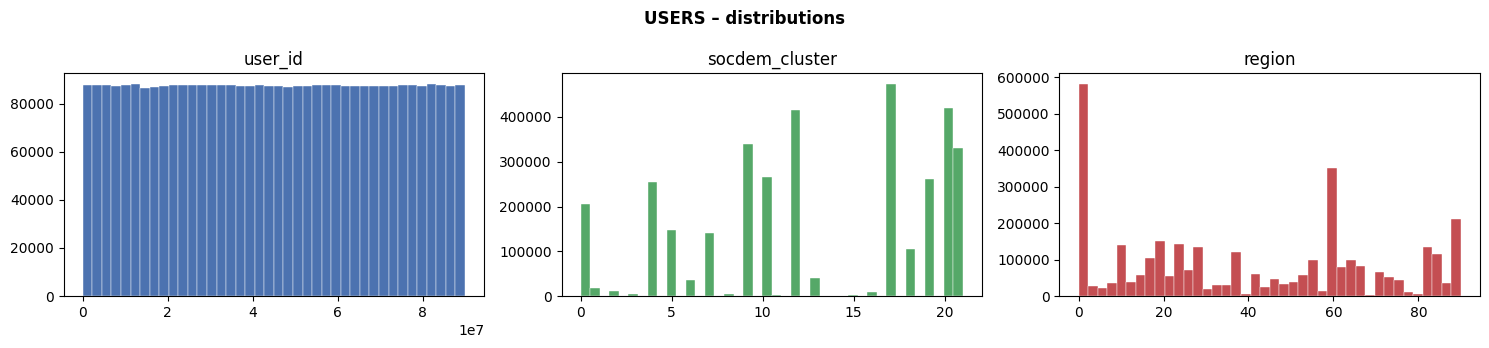

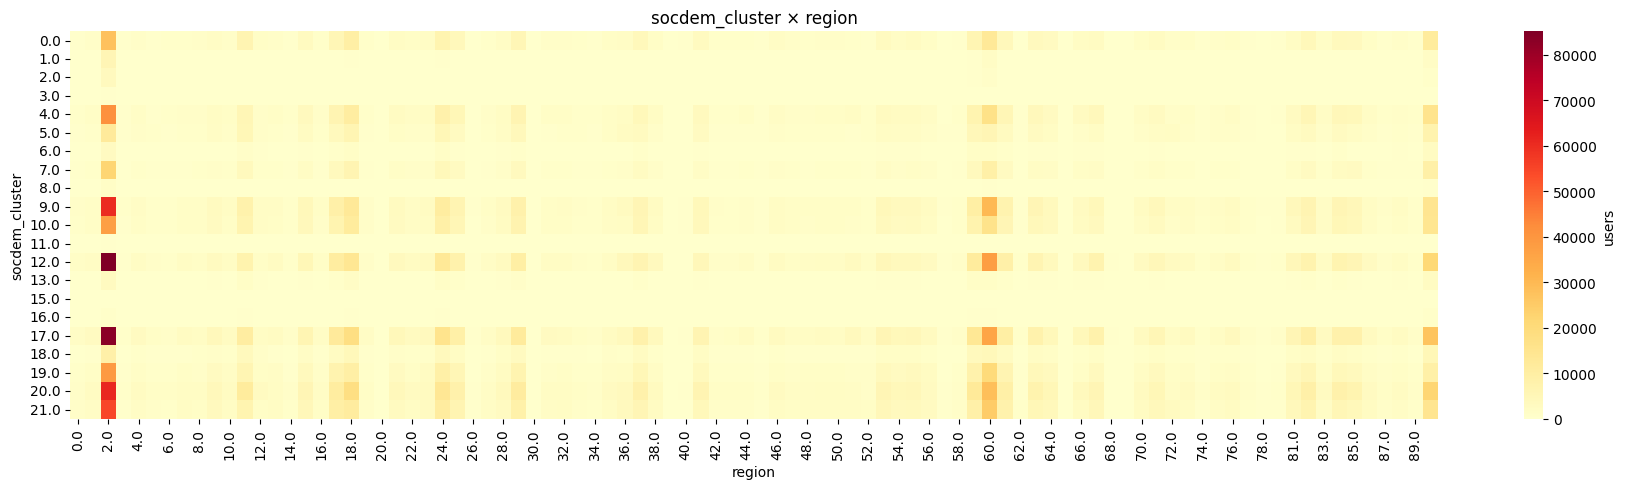

In [9]:
for col in ["socdem_cluster", "region"]:
    vc = USERS[col].value_counts(sort=True).with_columns(
        pct=(pl.col("count") / len(USERS) * 100).round(2)
    )
    print(f"\n{col} — n_unique={USERS[col].n_unique()}, null={USERS[col].is_null().mean()*100:.1f}%")
    display(HTML(vc.to_pandas().to_html(index=False)))

#  Numeric histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col, color in zip(axes, ["user_id", "socdem_cluster", "region"], ["#4C72B0", "#55A868", "#C44E52"]):
    ax.hist(USERS[col].to_numpy(), bins=40, color=color, edgecolor="white", lw=0.3)
    ax.set_title(col)
plt.suptitle("USERS – distributions", fontweight="bold")
plt.tight_layout()
plt.show()

# cluster × region heatmap
pivot = USERS.group_by(["socdem_cluster", "region"]).agg(pl.len().alias("n")).to_pandas()
pivot = pivot.pivot_table(index="socdem_cluster", columns="region", values="n", fill_value=0)
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0, cbar_kws={"label": "users"})
ax.set_title("socdem_cluster × region")
plt.tight_layout()
plt.show()

### Items

In [10]:
for col in ["category", "subcategory"]:
    vc = ITEMS[col].value_counts(sort=True).with_columns(
        pct=(pl.col("count") / len(ITEMS) * 100).round(2)
    )
    print(f"\n{col} — n_unique={ITEMS[col].n_unique()}, null={ITEMS[col].is_null().mean()*100:.1f}%")
    display(HTML(vc.to_pandas().to_html(index=False)))

print(f"\nbrand_id — n_unique={ITEMS['brand_id'].n_unique()}, null={ITEMS['brand_id'].is_null().mean()*100:.1f}%")
display(HTML(ITEMS["brand_id"].value_counts(sort=True).head(20).to_pandas().to_html(index=False)))


category — n_unique=23, null=41.6%


category,count,pct
NaN,966395,41.56
Miscellaneous Goods (Uncategorized),266146,11.45
"Cosmetics, Personal Care, and Health Maintenance Products",188412,8.10
"Fashion Accessories, Tech Add-ons, and Style Enhancements",167811,7.22
"Outerwear, Casual Apparel, and Specialized Workwear",153223,6.59
Footwear of All Types,103680,4.46
Electronic Devices and Gadgets,84282,3.62
Home Improvement and Countryside Retreat Essentials,83707,3.60
"Construction and Renovation Materials, Tools, and Equipment",83584,3.59
Home/Office Furniture and Interior Decor,64919,2.79



subcategory — n_unique=193, null=53.0%


subcategory,count,pct
NaN,1233023,53.02
Jewelry and Costume Jewelry,99751,4.29
Women's Clothing,82778,3.56
Women's Footwear,62212,2.68
Men's Clothing,46759,2.01
Perfumes and Aromatic Products,40281,1.73
Image Creation Cosmetics,36948,1.59
Plumbing Equipment,36773,1.58
Facial Cosmetics and Care Products,35922,1.54
Men's Footwear,33597,1.44



brand_id — n_unique=231, null=0.0%


brand_id,count
47917,227283
227580,207473
211031,160267
52917,116150
137356,113678
95522,77191
198171,71876
206282,65066
111440,46883
166770,46530



price — null=0.1%, min=-10.00, max=10.00


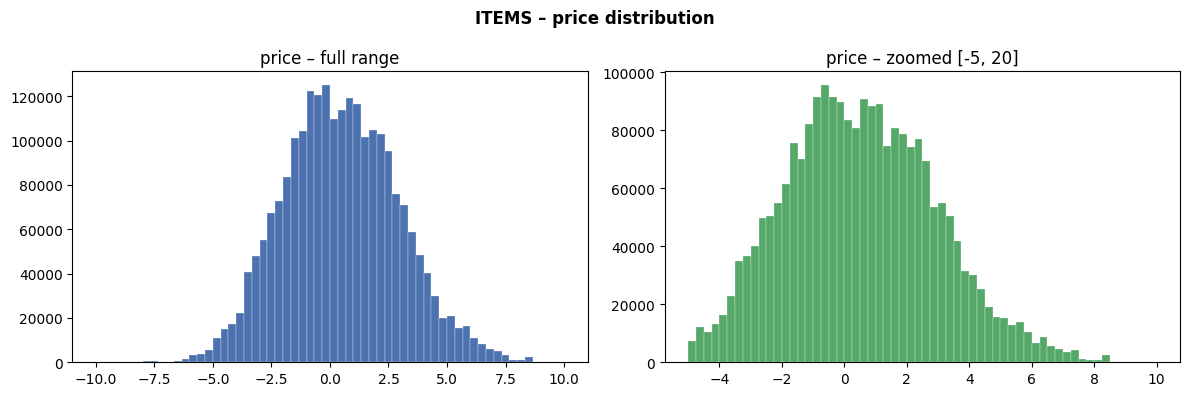

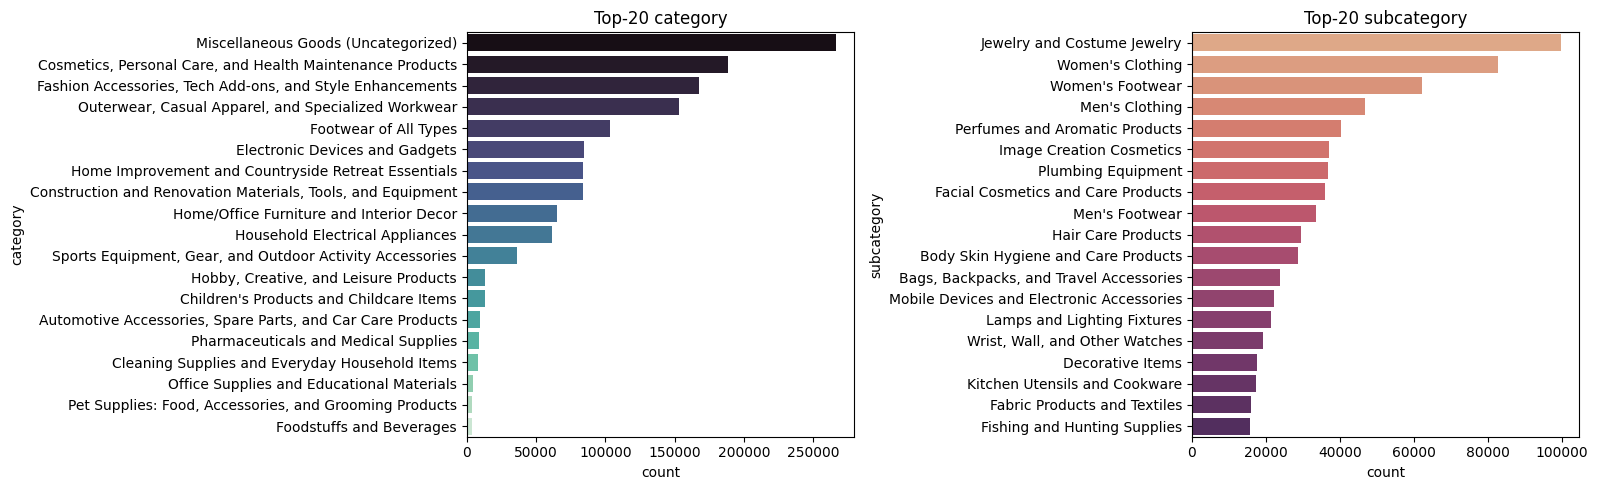

In [11]:
price = ITEMS["price"].drop_nulls().to_numpy()
print(f"\nprice — null={ITEMS['price'].is_null().mean()*100:.1f}%, min={price.min():.2f}, max={price.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price, bins=60, color="#4C72B0", edgecolor="white", lw=0.2)
axes[0].set_title("price – full range")
axes[1].hist(price[(price >= -5) & (price <= 20)], bins=60, color="#55A868", edgecolor="white", lw=0.2)
axes[1].set_title("price – zoomed [-5, 20]")
plt.suptitle("ITEMS – price distribution", fontweight="bold")
plt.tight_layout()
plt.show()

# Top-20 categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, palette in zip(axes, ["category", "subcategory"], ["mako", "flare"]):
    top = ITEMS[col].value_counts(sort=True).head(20).to_pandas()
    sns.barplot(data=top, x="count", y=col, palette=palette, ax=ax, hue=col, legend=False)
    ax.set_title(f"Top-20 {col}")
plt.tight_layout()
plt.show()

### Events

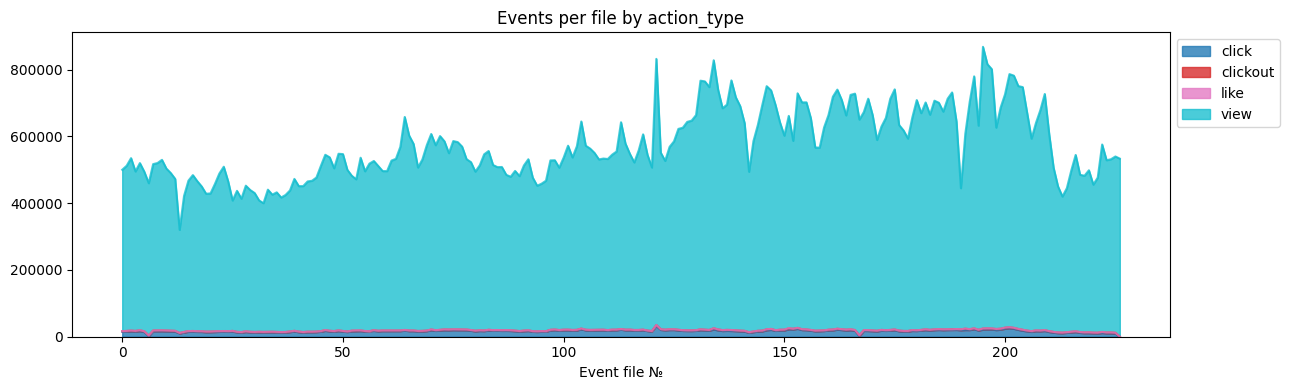

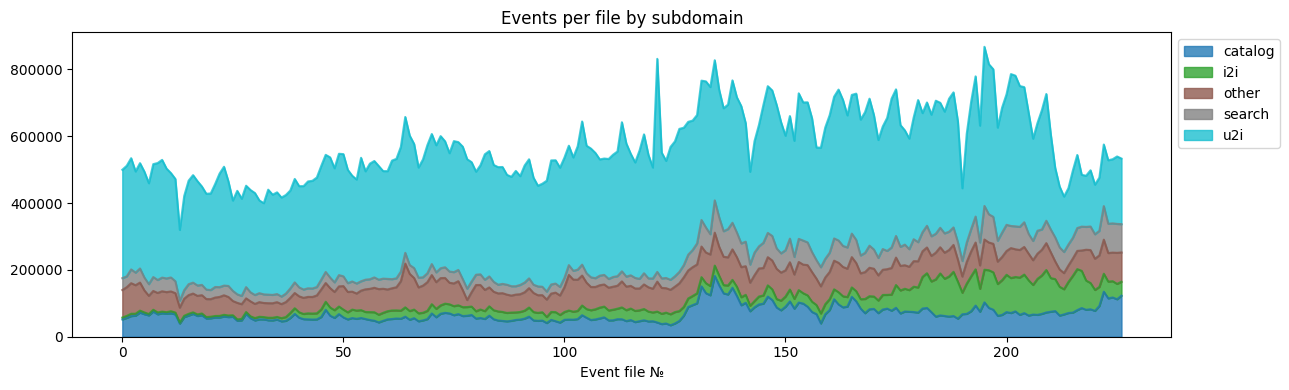

In [12]:
for groupby_col in ["action_type", "subdomain"]:
    rows = []
    for i, path in enumerate(EVENT_FILES):
        df = pl.read_parquet(path)
        for row in df[groupby_col].value_counts().iter_rows(named=True):
            rows.append({"file_no": i, groupby_col: row[groupby_col], "count": row["count"]})

    pivot = pd.DataFrame(rows).pivot_table(index="file_no", columns=groupby_col, values="count", fill_value=0)
    fig, ax = plt.subplots(figsize=(13, 4))
    pivot.plot(kind="area", stacked=True, ax=ax, alpha=0.78, colormap="tab10")
    ax.set_xlabel("Event file №")
    ax.set_title(f"Events per file by {groupby_col}")
    ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



All action_types: ['clickout', 'view', 'like', 'click']

Clickout pairs total : 427,192
Repeated (>1 click)  : 35,342 (8.3%)
Max clicks on one item by one user: 163


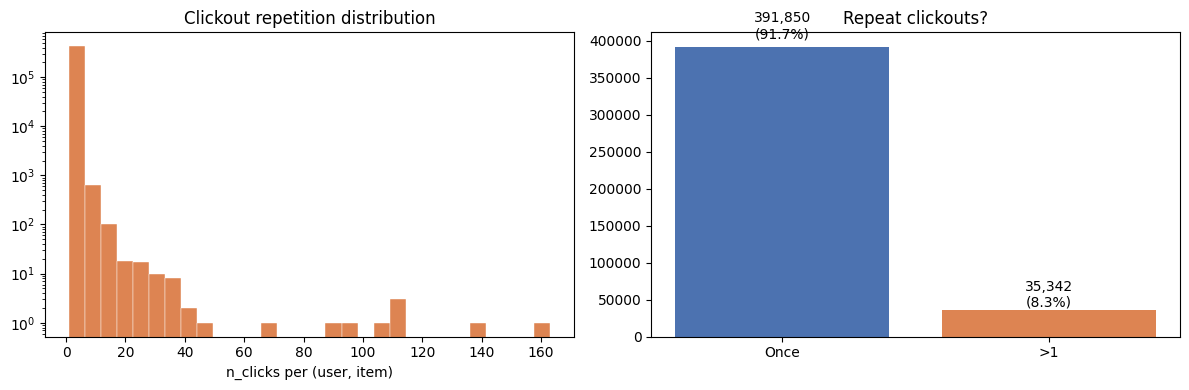

In [13]:
all_actions = EVENTS_LAZY.select("action_type").unique().collect()["action_type"].to_list()
print(f"\nAll action_types: {all_actions}")

clickout_action = next((a for a in all_actions if "click" in str(a).lower()), None)

if clickout_action is None:
    print("No clickout action found — dataset may only contain 'view' events.")
else:
    clickouts = (
        EVENTS_LAZY
        .filter(pl.col("action_type") == clickout_action)
        .group_by(["user_id", "item_id"])
        .agg(pl.len().alias("n_clicks"))
        .collect()
    )
    total    = len(clickouts)
    n_repeat = clickouts.filter(pl.col("n_clicks") > 1).height
    print(f"\nClickout pairs total : {total:,}")
    print(f"Repeated (>1 click)  : {n_repeat:,} ({n_repeat/total*100:.1f}%)")
    print(f"Max clicks on one item by one user: {clickouts['n_clicks'].max()}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(clickouts["n_clicks"].to_numpy(), bins=30, color="#DD8452", edgecolor="white", lw=0.3)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("n_clicks per (user, item)")
    axes[0].set_title("Clickout repetition distribution")

    bars = axes[1].bar(["Once", ">1"], [total - n_repeat, n_repeat], color=["#4C72B0", "#DD8452"])
    for bar, cnt in zip(bars, [total - n_repeat, n_repeat]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                     f"{cnt:,}\n({cnt/total*100:.1f}%)", ha="center", va="bottom")
    axes[1].set_title("Repeat clickouts?")
    plt.tight_layout()
    plt.show()

## Data Splitting (1p)

Прежде чем обучать какие-либо модели, разобъем данные на train-val-test по временной отметке (темпоральный сплит).

На практике обычно используется следующий подход: сначала модель обучается на train части, на val подбирается лучший набор гиперпараметров. Потом модель обучается на train+val, и финальные метрики замеряются на test.

Допишите функцию так, чтобы:

* в train вошли данные start_day < day <= start_day + n_train_days
* в val вошли данные start_day + n_train_days < day <= start_day + n_train_days + n_val_days
* в test вошли данные start_day + n_train_days + n_val_days < day <= start_day + n_train_days + n_val_days + n_test_days

Где start_day - это номер файла, задающий дату, с которой начинается временной промежуток.

Не будем учитывать повторные взаимодействия в обучающих данных. То есть для каждой пары (пользователь, айтем) в train/train_val необходимо оставить только максимальный лейбл.

Ожидаемую результирующую схему данных можно найти ниже. В val и test нужно оставить только позитивы.

In [12]:
def get_data(
    start_day: int = 1250,
    n_train_days: int = 20,
    n_val_days: int = 3,
    n_test_days: int = 5,
    n_users_to_keep: int = 10_000,
    n_items_to_keep: int = 30_000,
) -> tuple[pl.LazyFrame, pl.LazyFrame, pl.LazyFrame, pl.LazyFrame]:

    events = (
        pl.scan_parquet("dataset/small/marketplace/events/")
        .with_columns(
            label=(
                pl.when(pl.col("action_type") == "view")
                .then(0)
                .otherwise(1)
            )  # `label` равен 1, если `action_type` НЕ равен просмотру, и 0 иначе
        )
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
        )
        .sort("timestamp")
        .select("timestamp", "user_id", "item_id", "label")
    )

    # Отфильтруем топ-`n_users_to_keep` пользователей и топ-`n_items_to_keep` айтемов по количеству положительных взаимодействий
    # Это нужно, чтобы не обучать модели на слишком больших матрицах (потому что у нас тут всё-таки дз, а не полноценный продовый сетап)
    
    user_positive_counts = (
        events
        .group_by("user_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_users_to_keep)
        .select("user_id")
    )
    
    item_counts = (
        events
        .group_by("item_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_items_to_keep)
        .select("item_id")
    )

    # Кстати, у такого способа фильтрации точно есть проблемы - как минимум то, что что статистика для айтемов считается и по тем юзерам, 
    # которые не попали в топ-`n_users_to_keep`. Но в качестве приближения работает вполне неплохо 
    
    events_filtered = (
        events
        .join(user_positive_counts, on="user_id", how="inner")
        .join(item_counts, on="item_id", how="inner")
        .collect()
        .lazy()
    )


    train_end     = start_day + n_train_days
    val_end       = train_end + n_val_days
    test_end = val_end + n_test_days
    

    def dedup(lf: pl.LazyFrame) -> pl.LazyFrame:
        """For each (user, item) pair keep max label and latest timestamp."""
        return (
            lf
            .group_by("user_id", "item_id")
            .agg(pl.col("label").max(), pl.col("timestamp").max())
            .select("user_id", "item_id", "timestamp", "label")
            .with_columns(pl.col("label").cast(pl.Int32))
    )

    def to_positives(lf: pl.LazyFrame) -> pl.LazyFrame:
        """Keep only positive events, group item_ids into a list per user."""
        return (
            lf
            .filter(pl.col("label") == 1)
            .group_by("user_id")
            .agg(pl.col("item_id"))
        )

    train_events = dedup(
        events_filtered.filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= train_end)
        )
    )

    train_val_events = dedup(
        events_filtered.filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= val_end)
        )
    )

    val_events = to_positives(
        events_filtered.filter(
            (pl.col("timestamp").dt.total_days() > train_end) &
            (pl.col("timestamp").dt.total_days() <= val_end)
        )
    )

    test_events = to_positives(
        events_filtered.filter(
            (pl.col("timestamp").dt.total_days() > val_end) &
            (pl.col("timestamp").dt.total_days() <= test_end)
    )
)

    return (
        train_events, 
        val_events, 
        train_val_events, 
        test_events
    )


train_events, val_events, train_val_events, test_events = get_data()

train_events = train_events.collect()
val_events = val_events.collect()
train_val_events = train_val_events.collect()
test_events = test_events.collect()


In [13]:
train_events

user_id,item_id,timestamp,label
u64,str,duration[μs],i32
32537417,"""nfmcg_16960121""",1252d 3h 27m 8s 662841µs,0
65734353,"""nfmcg_13844419""",1263d 2h 52m 48s 179672µs,0
74951884,"""nfmcg_15350017""",1267d 20h 53m 26s 513047µs,0
22221383,"""nfmcg_716576""",1270d 12h 50m 29s 281389µs,0
37071755,"""nfmcg_15143377""",1268d 4h 6m 57s 558203µs,0
…,…,…,…
32884708,"""nfmcg_22493392""",1253d 12h 8m 51s 596022µs,1
26054708,"""nfmcg_26359073""",1270d 6h 58m 16s 360487µs,0
46679802,"""nfmcg_5453101""",1265d 16h 47m 46s 237803µs,0


In [14]:
expected_train_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.String,
    "timestamp": pl.Duration(time_unit='us'),
    "label": pl.Int32
})

expected_val_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.List(pl.String)
})

assert train_events.schema == expected_train_schema
assert val_events.schema == expected_val_schema
assert train_val_events.schema == expected_train_schema
assert test_events.schema == expected_val_schema

Отфильтруйте из валидационного и тестового подмножеств только теплых пользователей (то есть таких, у которых было хотя бы одно взаимодействие в train или train_val части соответственно). Почему так? Модели, которые рассматриваются в данном дз, не умеют работать с холодными пользователями. 

Кстати, сколько получается таких холодных пользователей?

In [15]:
train_users     = train_events.select("user_id").unique()
train_val_users = train_val_events.select("user_id").unique()
n_before_val, n_before_test = len(val_events), len(test_events)

val_events  = val_events.join(train_users,     on="user_id", how="inner")
test_events = test_events.join(train_val_users, on="user_id", how="inner")

print(f"Cold users — val: {n_before_val - len(val_events):,}, test: {n_before_test - len(test_events):,}")


Cold users — val: 313, test: 387


In [16]:
len(train_events), len(val_events), len(train_val_events), len(test_events)

(693076, 2369, 781805, 3499)

In [17]:
assert len(train_events) == 693176
assert len(val_events) == 2375
assert len(train_val_events) == 782473
assert len(test_events) == 3488

#Писали, что если значения близкие , то можно и так оставить

AssertionError: 

In [18]:
assert round(train_events["label"].mean(), 2) == 0.12
assert round(train_val_events["label"].mean(), 2) == 0.12

In [19]:
val_users = val_events["user_id"].to_list()
test_users = test_events["user_id"].to_list()

## Evaluation (1p)

In [20]:
# сколько рекомендаций будем выдавать для каждого пользователя. можете выбрать другое число 
N = 20

### Metrics (0.5p)

Реализуйте набор метрик для оценки качества моделей. Обязательно реализовать HitRate@k (можно взять из прошлой домашки) и Coverage@k. NDCG@k и Recall@k уже реализованы. По желанию можете добавить и другие метрики, например MAP@k, MRR@k и Precision@k.

Условия на векторизацию/обязательность использования polars-а в метриках нет :)

In [21]:
def hit_rate(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    hits = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:
            hits.append(0.0)
            continue

        hit = 1.0 if any(item in user_truth for item in user_recs) else 0.0
        hits.append(hit)

    return float(np.mean(hits)) if hits else 0.0


def recall(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    recalls = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:  # If no ground truth items, recall is 0
            recalls.append(0.0)
            continue

        relevant_count = sum(1 for item in user_recs if item in user_truth)
        user_recall = relevant_count / len(user_truth)
        recalls.append(user_recall)

    return np.mean(recalls) if recalls else 0.0


def ndcg(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level for evaluation
    """
    def dcg(scores):
        return np.sum(
            np.divide(
                np.power(2, scores) - 1,
                np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)
            ),
            dtype=np.float64
        )
    
    ndcg_scores = []
    
    for user_id, pred_items in recommendations.items():
        pred = pred_items[:k]
        gt_set = ground_truth.get(user_id, set())
        
        # Создаем бинарный вектор релевантности для рекомендованных элементов
        # Размер: min(k, len(pred)) - мы оцениваем только первые k рекомендованных
        at = len(pred)
        
        # Для DCG: релевантность рекомендованных элементов
        relevance = np.array([1.0 if item in gt_set else 0.0 for item in pred], dtype=np.float64)
        
        rank_dcg = dcg(relevance)
        
        if rank_dcg == 0.0:
            ndcg_scores.append(0.0)
            continue
        
        # Для IDCG: идеальный случай - все релевантные элементы в начале
        # Берем все релевантные элементы (из ground truth)
        # Но не больше, чем мы можем разместить в рекомендациях длины at
        # Создаем массив из 1 для релевантных и 0 для нерелевантных, сортируем по убыванию
        all_relevances = np.ones(len(gt_set), dtype=np.float64)
        ideal_relevance = np.sort(np.concatenate([all_relevances, np.zeros(max(0, at - len(gt_set)))]))[::-1][:at]
        
        # Вычисляем IDCG
        ideal_dcg = dcg(ideal_relevance)
        
        if ideal_dcg == 0.0:
            ndcg_scores.append(0.0)
        else:
            ndcg_ = rank_dcg / ideal_dcg
            ndcg_scores.append(ndcg_)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0
    

def coverage(recommendations, catalog_size=CATALOG_SIZE, k=100):
    """
    Args:
       recommendations: dict {user_id: list of recommended item_ids}
       catalog_size: total number of unique items in the catalog
       k: cutoff level
    """
    if catalog_size <= 0:
        return 0.0

    recs_iter = recommendations.values() if isinstance(recommendations, dict) else recommendations
    recommended = {item for recs in recs_iter for item in recs[:k]}
    return len(recommended) / catalog_size


Микро-тест:

In [22]:
recommendations = {
    'user1': ['item1', 'item2', 'item3', 'item4', 'item5'],
    'user2': ['item2', 'item1', 'item4', 'item5', 'item3'],
    'user3': ['item5', 'item4', 'item3', 'item2', 'item1'],
    'user4': ['item6', 'item7', 'item8', 'item9', 'item10'],
}
ground_truth = {
    'user1': {'item1', 'item3'},
    'user2': {'item1', 'item2', 'item4'},
    'user3': {'item5'},
    'user4': set(),
}

hr_val = hit_rate(recommendations, ground_truth, 3)
assert np.isclose(hr_val, 0.75, atol=1e-2), f"Expected HitRate 0.75, got {hr_val}"

rec_val = recall(recommendations, ground_truth, 3)
assert np.isclose(rec_val, 0.75, atol=1e-2), f"Expected Recall 0.75, got {rec_val}"

ndcg_val = ndcg(recommendations, ground_truth, 3)
assert np.isclose(ndcg_val, 0.73, atol=1e-2), f"Expected NDCG ~0.73, got {ndcg_val}"

coverage_val = coverage(recommendations, catalog_size=20, k=10)
assert np.isclose(coverage_val, 0.5, atol=1e-2), f"Expected Coverage ~0.5, got {coverage_val}"

Создадим функцию, которая будет приводить polars-таблицу с рекомендациями в удобный для расчета метрик вид. Если вы добавляли свои метрики - добавьте их и сюда тоже. 

In [23]:
def _evaluate(recommendations, ground_truth, k):
    results = {}
    
    for k_ in k:
        hr = hit_rate(recommendations, ground_truth, k=k_)
        rec = recall(recommendations, ground_truth, k=k_)
        ndcg_score = ndcg(recommendations, ground_truth, k=k_)
        coverage_score = coverage(recommendations, k=k_)
        
        results[f"hit_rate@{k_}"] = hr
        results[f"recall@{k_}"] = rec
        results[f"ndcg@{k_}"] = ndcg_score
        results[f"coverage@{k_}"] = coverage_score
    
    return results


def evaluate(
    events: pl.DataFrame, 
    recommendations_column: str, 
    ground_truth_column: str = "item_id", 
    k=[5, 10, 20]
):
    recommendations = dict(events.select("user_id", recommendations_column).iter_rows())
    ground_truth = dict(events.select("user_id", ground_truth_column).iter_rows())
    return _evaluate(recommendations, ground_truth, k=k)

Общая табличка с метриками. Будем собирать её шаг за шагом:

In [24]:
%%time

test_events = test_events.with_columns(aa=pl.col("item_id").list.slice(0, N))
metrics_aa = evaluate(test_events, recommendations_column="aa")
RESULTS = pd.concat([
    pd.DataFrame(metrics_aa, index=["A/A"]),  # sanity check
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

CPU times: user 455 ms, sys: 10.7 ms, total: 466 ms
Wall time: 595 ms


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293


Как думаете, зачем может быть полезно проводить A/A тесты? Ответьте письменно. 

>A/A-тесты полезны, чтобы проверить экспериментальную систему: корректность рандомизации и сплита, качество трекинга метрик, частоту ложных “значимых” результатов, дисперсию метрик  — то есть убедиться, что A/B-тестам можно доверять.

### Exploration (0.5p)

Допишите функцию для оценки предсказаний моделей. Минимально она должна выводить график Popularity Bias (см. семинар) и топ-10 самых частотных рекомендаций с их признаками. Также интересно может быть посмотреть на преобладание каких-либо категорий/брендов и распределение стоимости айтемов в разных квантилях по частотности встречаемости в рекомендациях.

In [25]:
def explore_recommendations(model_recommendations: list[list]):
    """
    Args:
       model_recommendations: list[list of recommended item_ids] - список рекомендаций для каждого пользователя
    """
    global ITEMS

    # ── Flatten and count ────────────────────────────────────────────────────›
    counts = Counter(item for recs in model_recommendations for item in recs)
    freq_df = (
        pl.DataFrame({"item_id": list(counts.keys()), "rec_count": list(counts.values())})
        .sort("rec_count", descending=True)
        .join(ITEMS.drop("embedding"), on="item_id", how="left")
    )

    # ── 1. Popularity Bias ───────────────────────────────────────────────────
    rec_counts = freq_df["rec_count"].to_numpy()
    cumsum = rec_counts.cumsum() / rec_counts.sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(range(len(cumsum)), cumsum, lw=1.5)
    axes[0].axhline(0.5, color="red", lw=0.8, linestyle="--", label="50% of recs")
    axes[0].set_xlabel("Item rank (by recommendation frequency)")
    axes[0].set_ylabel("Cumulative share of recommendations")
    axes[0].set_title("Popularity Bias – cumulative distribution")
    axes[0].legend()

    axes[1].bar(range(min(50, len(rec_counts))), rec_counts[:50], color="#4C72B0", width=1.0)
    axes[1].set_xlabel("Item rank")
    axes[1].set_ylabel("# times recommended")
    axes[1].set_title("Top-50 items by recommendation frequency")
    plt.tight_layout()
    plt.show()

    n_items_cover_50pct = int((cumsum < 0.5).sum()) + 1
    print(f"Top-{n_items_cover_50pct} items account for 50% of all recommendations "
          f"out of {len(rec_counts):,} unique items recommended")

    # ── 2. Top-10 most recommended items with features ───────────────────────
    print("\n── Top-10 most recommended items ──")
    display(HTML(freq_df.head(10).to_pandas().to_html(index=False)))

    # ── 3. Category & subcategory breakdown ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, col, palette in zip(axes, ["category", "subcategory"], ["mako", "flare"]):
        top = (
            freq_df.group_by(col)
            .agg(pl.col("rec_count").sum())
            .sort("rec_count", descending=True)
            .head(15)
            .to_pandas()
        )
        sns.barplot(data=top, x="rec_count", y=col, hue=col, palette=palette, legend=False, ax=ax)
        ax.set_title(f"Recommendations by {col} (top-15)")
        ax.set_xlabel("Total times recommended")
    plt.tight_layout()
    plt.show()

    # ── 4. Brand breakdown ───────────────────────────────────────────────────
    top_brands = (
        freq_df.group_by("brand_id")
        .agg(pl.col("rec_count").sum())
        .sort("rec_count", descending=True)
        .head(20)
        .to_pandas()
    )
    top_brands["brand_id"] = top_brands["brand_id"].astype(str)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top_brands, x="rec_count", y="brand_id",
                hue="brand_id", palette="rocket", legend=False, ax=ax)
    ax.set_title("Top-20 brands by recommendation frequency")
    ax.set_xlabel("Total times recommended")
    plt.tight_layout()
    plt.show()

## Baselines (1.5p)

In [26]:
class BaseRecommender(ABC):
    """
    Base recommender class. All models should inherit from this.
    Defines common interface and stores column name configuration.
    """
    def __init__(self, name: str = ""):
        self.name = name
        self.user_col = "user_id"
        self.item_col = "item_id"
        self.interactions_col = "label"
        self.fitted = False

    @abstractmethod
    def _fit(self, interactions: pl.DataFrame):
        """Fit model on interaction data."""
        pass

    @abstractmethod
    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        """Recommend for list of users. Returns list of [item_id], len([item_id])=topn, corresponding to each user."""
        pass

    def fit(self, interactions: pl.DataFrame):
        self._fit(interactions)
        self.fitted = True

    def recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        if not self.fitted:
            raise ValueError("Model is not fitted yet, call fit() first")
            
        return self._recommend(user_ids, topn)

### Random (0.5p)

Самая простая модель уже написана за вас. Обратите внимание, что разные способы сэмплирования дают разные временные оценки. Векторные операции зачастую сильно ускоряют вычисления. 

In [27]:
class RandomRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="random")
        self.items = []

    def _fit(self, interactions: pl.DataFrame):
        self.items = interactions[self.item_col].unique().to_list()

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        # a cycle + df.sample will work for 2 hours
        return np.random.choice(self.items, size=(len(user_ids), topn), replace=True)

In [28]:
model = RandomRecommender()

In [29]:
%%time
model.fit(train_val_events)

CPU times: user 50.1 ms, sys: 807 µs, total: 50.9 ms
Wall time: 51.7 ms


In [30]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 8.72 ms, sys: 940 µs, total: 9.66 ms
Wall time: 18.4 ms


In [31]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078


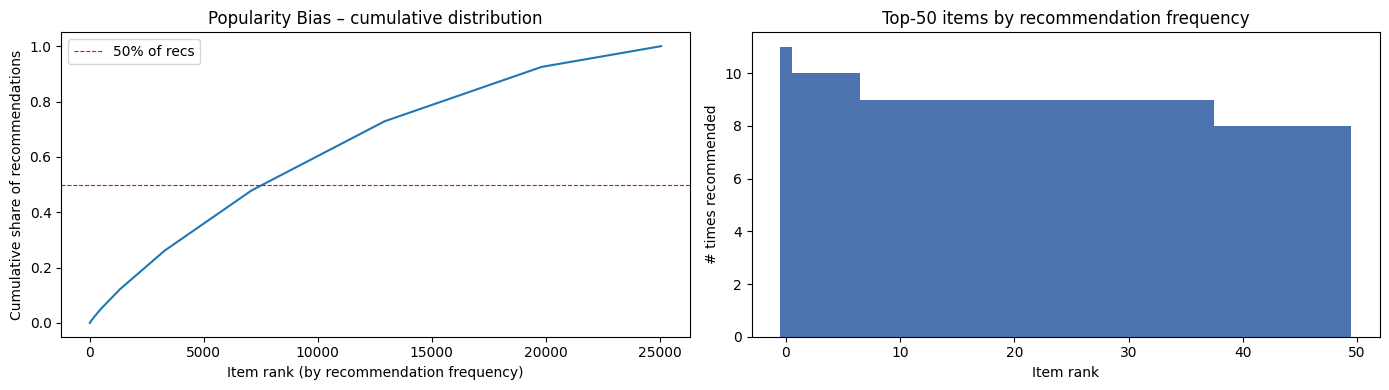

Top-7594 items account for 50% of all recommendations out of 25,068 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_8105380,11,165269,Miscellaneous Goods (Uncategorized),None,0.498454
nfmcg_20378746,10,233267,Electronic Devices and Gadgets,Gaming Electronic Devices,5.283687
nfmcg_18307866,10,211031,"Cosmetics, Personal Care, and Health Maintenance Products",Facial Cosmetics and Care Products,-0.916488
nfmcg_15577575,10,12499,None,None,0.036760
nfmcg_318120,10,39543,"Outerwear, Casual Apparel, and Specialized Workwear",Women's Clothing,2.389780
nfmcg_6070689,10,166770,Miscellaneous Goods (Uncategorized),None,1.747280
nfmcg_19566862,10,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,2.823474
nfmcg_14478195,9,190801,"Cosmetics, Personal Care, and Health Maintenance Products",Image Creation Cosmetics,-0.621622
nfmcg_3431769,9,211031,Pharmaceuticals and Medical Supplies,Dietary Supplements and Vitamins,-0.557661
nfmcg_11808944,9,47917,Miscellaneous Goods (Uncategorized),None,-0.407680


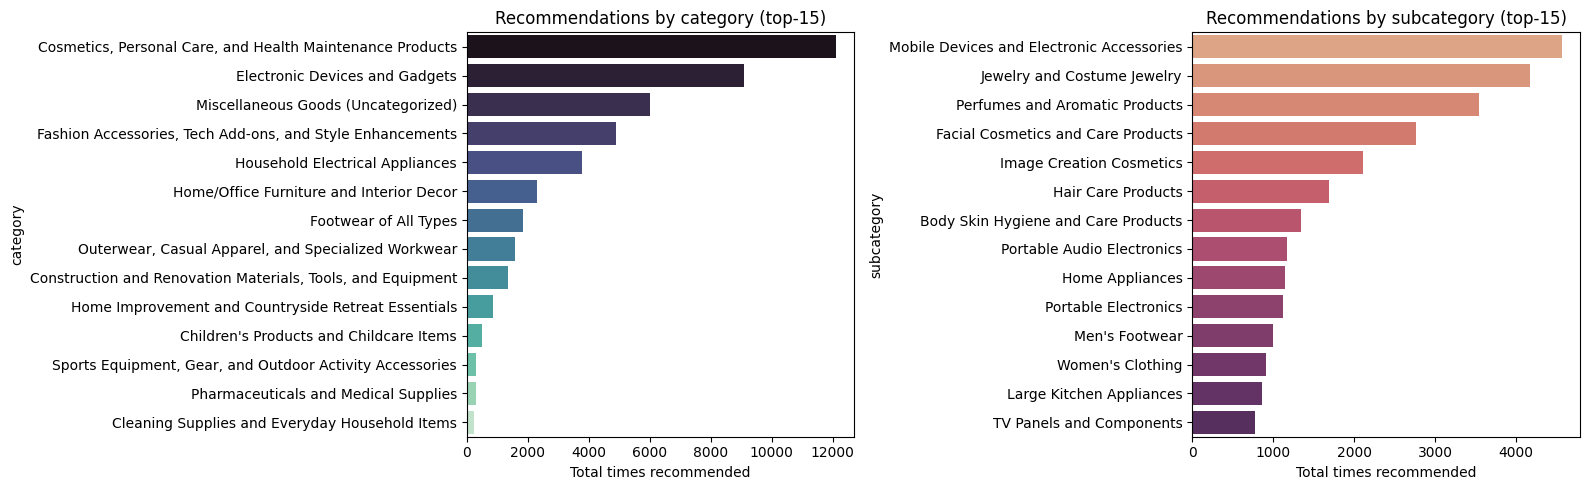

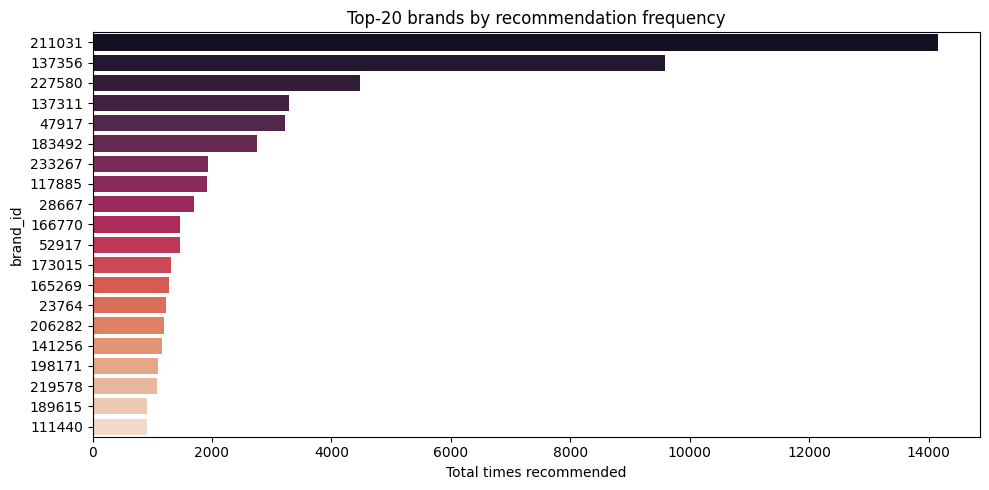

In [32]:
explore_recommendations(model_recommendations)

В следующей ячейке письменно ответьте на вопрос, когда может пригодиться "подмешивание случайных рекомендаций" в выдачу? Как бы вы реализовали подобное подмешивание (идейно и с точки зрения способа сэмплирования)? Какие ограничения есть у предложенного подхода?

Подмешивание случайных рекомендаций полезно для того,чтобы: собрать новые сигналы, продвинуть **cold-start айтемы**, снизить **popularity bias**, увеличить **coverage/разнообразие**.

Как реализовать:

*  берём top-K модели и заменяем (m) позиций (с  хвоста) на случайные рекоммендации.

Сэмплировать лучше не равномерно по всему каталогу, а из eligible-пула (в наличии, разрешено, подходит по региону/языку, не показывали недавно и так далее).

Ограничения:

* может **просесть CTR/конверсия**;
* риск показать “мусор” => нужны жёсткие фильтры;
* возможно раздражение части пользователей  неактуальными рекомендациями - надо строго контролировать число случайных рекомендаций

### TopPopular

Еще одна уже написанная моделька :)

Популярность айтема считается как суммарное количество положительных взаимодействий с ним. 

In [33]:
class TopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="toppop")
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        self.popular_items = (
            interactions
            .group_by(self.item_col).agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True).head(self.inner_cutoff)
            [self.item_col].to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)

In [34]:
model = TopPopularRecommender()

In [35]:
%%time
model.fit(train_val_events)

CPU times: user 81.5 ms, sys: 0 ns, total: 81.5 ms
Wall time: 43.4 ms


In [36]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 19 µs, sys: 0 ns, total: 19 µs
Wall time: 21.9 µs


In [37]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001


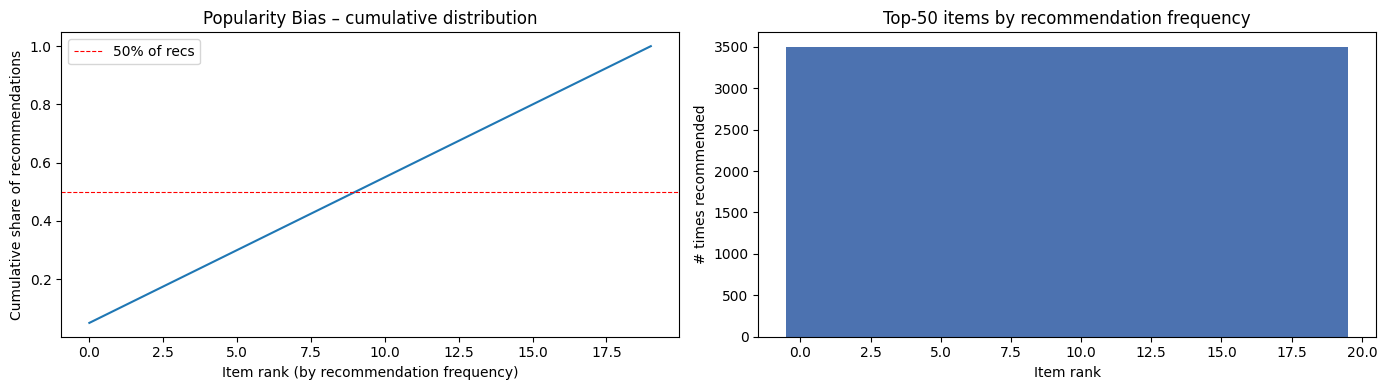

Top-10 items account for 50% of all recommendations out of 20 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_18106422,3499,137311,Miscellaneous Goods (Uncategorized),None,1.655624
nfmcg_8797298,3499,137356,Miscellaneous Goods (Uncategorized),None,4.558963
nfmcg_8957656,3499,80160,Miscellaneous Goods (Uncategorized),None,0.786800
nfmcg_12977198,3499,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.725761
nfmcg_9041331,3499,117885,Household Electrical Appliances,Home Care and Health Appliances,4.019646
nfmcg_7763862,3499,117885,Electronic Devices and Gadgets,Portable Audio Electronics,2.405509
nfmcg_27366316,3499,117885,Electronic Devices and Gadgets,TV Panels and Components,8.402068
nfmcg_22204691,3499,117885,Electronic Devices and Gadgets,Portable Audio Electronics,3.325357
nfmcg_25928977,3499,238130,Home/Office Furniture and Interior Decor,Cabinets and Storage Systems,5.609664
nfmcg_716576,3499,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,8.020088


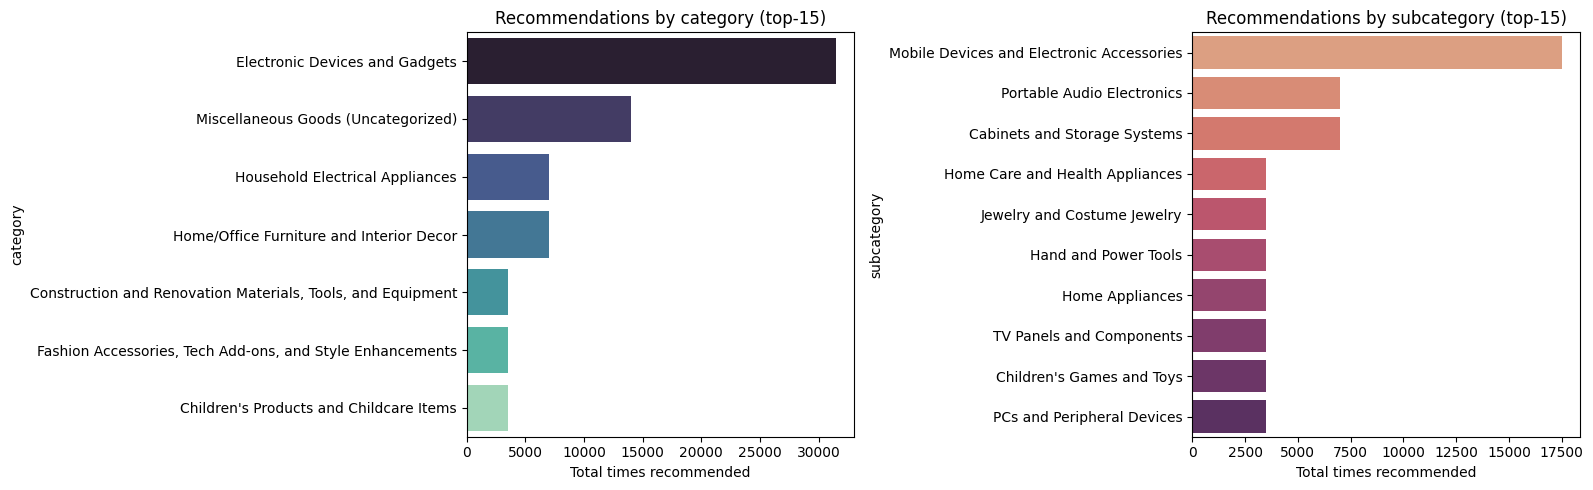

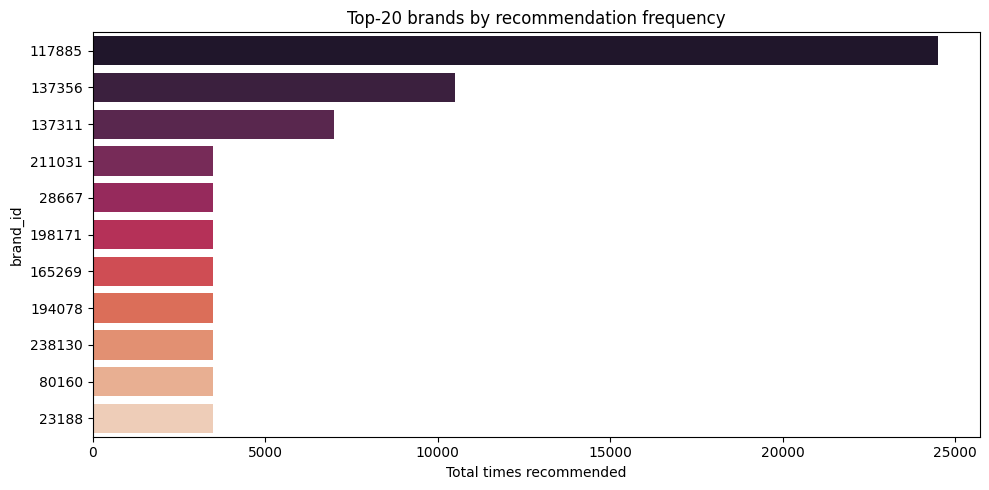

In [38]:
explore_recommendations(model_recommendations)

### SocdemTopPopular (1p)

А вот следующую модель вам придется реализовать самостоятельно. Идея в том, чтобы посчитать свой топ популярных айтемов для каждого соцдем-кластера пользователей (используйте `group_by`). Обратите внимание, что в случае, если на инференсе кластер не определен, нужно рекомендовать глобальный топ популярных айтемов, рассчитанный без учета кластеров.

Популярность айтема считается как суммарное количество положительных взаимодействий с ним.

In [39]:
class SocdemTopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="socdem_toppop")
        self.socdem_col = "socdem_cluster"
        self.inner_cutoff = 200
        self.popular_items = []           
        self.cluster_popular_items = {}   

    def _fit(self, interactions: pl.DataFrame):
        self.popular_items = (
            interactions
            .group_by(self.item_col)
            .agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True)
            .head(self.inner_cutoff)
            [self.item_col].to_list()
        )

        interactions_with_cluster = interactions.join(
            USERS.select(["user_id", self.socdem_col]),
            on="user_id",
            how="left",
        )

        cluster_tops = (
            interactions_with_cluster
            .group_by([self.socdem_col, self.item_col])
            .agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True)
            .group_by(self.socdem_col)
            .agg(pl.col(self.item_col).head(self.inner_cutoff))
        )

        self.cluster_popular_items = {
            row[self.socdem_col]: row[self.item_col]
            for row in cluster_tops.iter_rows(named=True)
        }

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        global USERS

        user_clusters = (
            pl.DataFrame({"user_id": user_ids})
            .join(USERS.select(["user_id", self.socdem_col]), on="user_id", how="left")
            [self.socdem_col].to_list()
        )

        return [
            (self.cluster_popular_items.get(cluster) or self.popular_items)[:topn]
            for cluster in user_clusters
        ]

In [40]:
model = SocdemTopPopularRecommender()

In [41]:
%%time
model.fit(train_val_events)

CPU times: user 612 ms, sys: 35.8 ms, total: 647 ms
Wall time: 623 ms


In [42]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 297 ms, sys: 33.1 ms, total: 330 ms
Wall time: 233 ms


In [43]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005


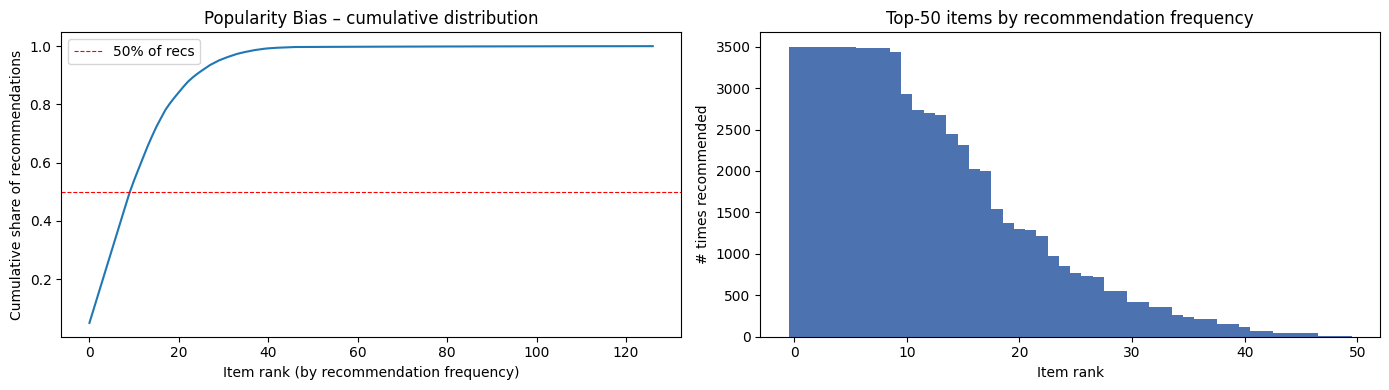

Top-11 items account for 50% of all recommendations out of 127 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_8797298,3498,137356,Miscellaneous Goods (Uncategorized),None,4.558963
nfmcg_18106422,3496,137311,Miscellaneous Goods (Uncategorized),None,1.655624
nfmcg_12977198,3494,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.725761
nfmcg_9041331,3494,117885,Household Electrical Appliances,Home Care and Health Appliances,4.019646
nfmcg_7763862,3494,117885,Electronic Devices and Gadgets,Portable Audio Electronics,2.405509
nfmcg_716576,3491,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,8.020088
nfmcg_27366316,3489,117885,Electronic Devices and Gadgets,TV Panels and Components,8.402068
nfmcg_8957656,3485,80160,Miscellaneous Goods (Uncategorized),None,0.786800
nfmcg_22204691,3482,117885,Electronic Devices and Gadgets,Portable Audio Electronics,3.325357
nfmcg_25928977,3439,238130,Home/Office Furniture and Interior Decor,Cabinets and Storage Systems,5.609664


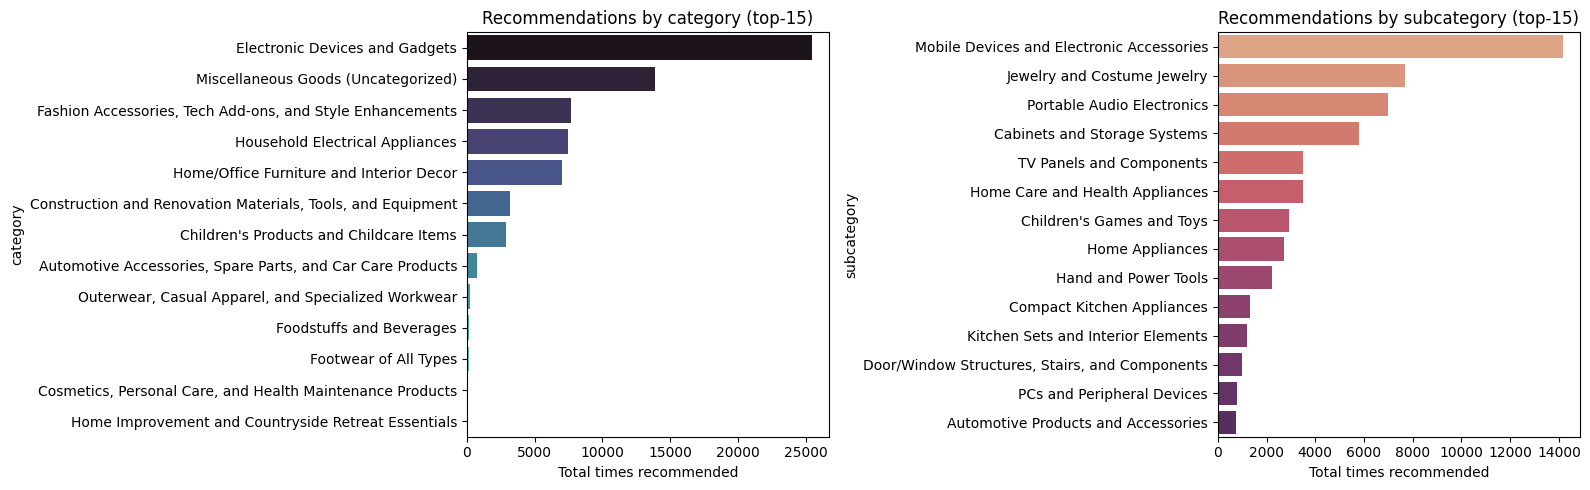

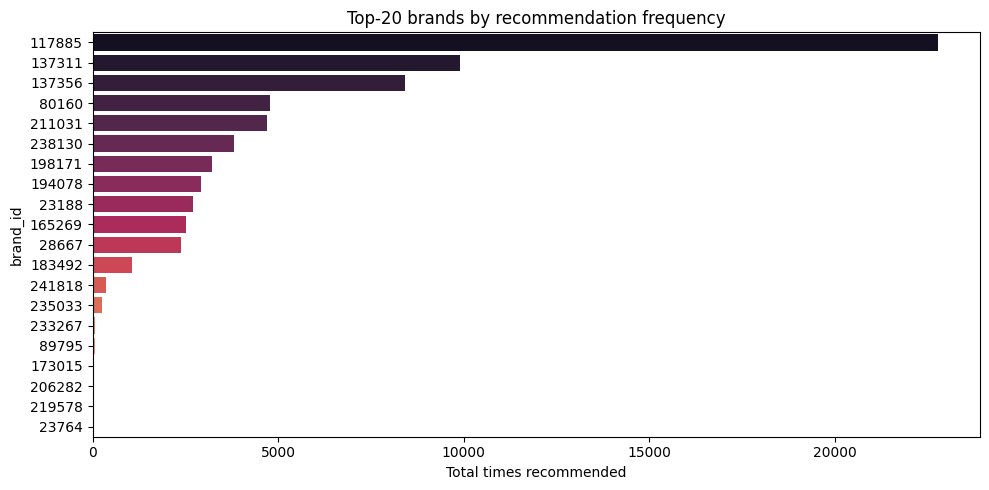

In [44]:
explore_recommendations(model_recommendations)

## MF (3.5p)

In [45]:
class BaseMFRecommender(BaseRecommender):
    """
    Base class for matrix factorization recommenders.
    Adds user/item ID mapping and interaction matrix construction.
    """
    def __init__(self, name: str = ""):
        super().__init__(name=name)
        
        self.id2user = {}
        self.id2item = {}

        self.user2id = {}
        self.item2id = {}
        
        self.interactions_matrix: csr_matrix = None

    def _create_interaction_matrix(self, interactions: pl.DataFrame):
        """Create CSR interaction matrix and mappings. To be used in _fit() method"""
        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()
        
        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}
        
        rows = [self.user2id[user] for user in interactions[self.user_col]]
        cols = [self.item2id[item] for item in interactions[self.item_col]]
        
        self.interactions_matrix = csr_matrix(
            (interactions[self.interactions_col], (rows, cols)),
            shape=(len(unique_users), len(unique_items)),
            dtype=np.float32,  # лучше всегда указывать тип, чтобы не было проблем с памятью
        )

### Matrix operations (0.5p)

Простая задачка на вспомнить, как работать с матрицами. Реализуйте TopPopularRecommender как наследника класса BaseMFRecommender. Для расчетов популярных айтемов используйте матрицу интеракций вместо исходной polars-таблицы. Проверьте, что результаты совпадают с обычным TopPopularRecommender.

In [46]:
class TopPopularMFRecommender(BaseMFRecommender):
    def __init__(self):
        super().__init__(name="toppop_mf")
        self.popular_items = []
        self.inner_cutoff = 200

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)

        # Sum each column (item) across all users → popularity score
        item_popularity = np.asarray(self.interactions_matrix.sum(axis=0)).flatten()

        top_indices = np.argsort(item_popularity)[::-1][:self.inner_cutoff]
        self.popular_items = [self.id2item[i] for i in top_indices]

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)


model_mf = TopPopularMFRecommender()
model_mf.fit(train_val_events)

model_toppop = TopPopularRecommender()
model_toppop.fit(train_val_events)

test_users_sample = test_users[:100]
recs_mf     = model_mf.recommend(test_users_sample, topn=10)
recs_toppop = model_toppop.recommend(test_users_sample, topn=10)

recs_mf == recs_toppop

True

Здесь могло бы быть задание на реализацию SVD в качестве рекомедательной модели, но на практике она скорее не используется, поэтому - для желающих - остается на самостоятельное изучение :)

### iALS (2p)

#### Model (1p)

А вот что используется на практике, так это модель iALS из библиотеки `implicit`. Реализуйте iALSRecommender(BaseMFRecommender) как обертку для данной модели. Обратите внимание, что модель из коробки умеет рекомендовать для батча пользователей.

In [47]:
class iALSRecommender(BaseMFRecommender):
    def __init__(self, factors=64, iterations=15, regularization=0.01, alpha=1.0):
        super().__init__(name="ials")
        self.model = AlternatingLeastSquares(
            factors=factors,
            iterations=iterations,
            regularization=regularization,
            alpha=alpha,
            random_state=42,
        )

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        self.model.fit(self.interactions_matrix)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        row_ids = np.array([self.user2id[u] for u in user_ids if u in self.user2id])
        item_indices, _ = self.model.recommend(
            row_ids,
            self.interactions_matrix[row_ids],
            N=topn,
            filter_already_liked_items=True,
        )

        return [[self.id2item[i] for i in row] for row in item_indices]


model = iALSRecommender(factors=64, iterations=15, regularization=0.01)

Подберите лучшие гиперпарметры `factors`, `regularization`, `alpha` на валидационной выборке. Замерьте не только метрики качества, но и время обучения и инференса моделей.

Обучите лучшую модель на train+val и сделайте предсказания для test так же, как с предыдущими моделями. 

In [48]:
param_grid = {
    "factors"       : [32, 64],
    "regularization": [0.01, 0.1],
    "alpha"         : [1.0, 10.0, 40.0],
}

val_users = val_events["user_id"].to_list()
gt_val = dict(zip(
    val_events["user_id"].to_list(),
    [set(items) for items in val_events["item_id"].to_list()],
))

tuning_results = []

for factors, regularization, alpha in itertools.product(
    param_grid["factors"],
    param_grid["regularization"],
    param_grid["alpha"],
):
    model = iALSRecommender(
        factors=factors,
        iterations=15,
        regularization=regularization,
        alpha=alpha,
    )

    t0 = time.perf_counter()
    model.fit(train_events)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    val_recs = model.recommend(val_users, topn=N)
    inference_time = time.perf_counter() - t0

    recs_dict = dict(zip(val_users, val_recs))
    row = {
        "factors"       : factors,
        "regularization": regularization,
        "alpha"         : alpha,
        "fit_sec"       : round(fit_time, 2),
        "inference_sec" : round(inference_time, 3),
        "hit_rate"      : round(hit_rate(recs_dict, gt_val, k=N), 4),
        "recall"        : round(recall(recs_dict, gt_val, k=N), 4),
        "ndcg"          : round(ndcg(recs_dict, gt_val, k=N), 4),
        "coverage"      : round(coverage(val_recs, catalog_size=CATALOG_SIZE, k=N), 4),
    }
    tuning_results.append(row)
    print(
        f"factors={factors:3d}  reg={regularization:.3f}  alpha={alpha:5.1f} | "
        f"fit={fit_time:5.1f}s  infer={inference_time:.2f}s | "
        f"HR={row['hit_rate']:.4f}  NDCG={row['ndcg']:.4f}  Recall={row['recall']:.4f}"
    )

tuning_df = pd.DataFrame(tuning_results).sort_values("ndcg", ascending=False)
display(tuning_df.style.format(precision=4).background_gradient(cmap="Blues"))


best = tuning_df.iloc[0]
print(f"\nBest:  factors={int(best.factors)}  reg={best.regularization}  alpha={best.alpha}")
print(f"Val:   NDCG={best.ndcg:.4f}  HR={best.hit_rate:.4f}  Recall={best.recall:.4f}")


  0%|          | 0/15 [00:00<?, ?it/s]

factors= 32  reg=0.010  alpha=  1.0 | fit=  1.5s  infer=0.05s | HR=0.2246  NDCG=0.0338  Recall=0.0596


  0%|          | 0/15 [00:00<?, ?it/s]

factors= 32  reg=0.010  alpha= 10.0 | fit=  0.7s  infer=0.02s | HR=0.2267  NDCG=0.0350  Recall=0.0619


  0%|          | 0/15 [00:00<?, ?it/s]

...

factors= 64  reg=0.100  alpha= 10.0 | fit=  0.8s  infer=0.02s | HR=0.1452  NDCG=0.0221  Recall=0.0346


  0%|          | 0/15 [00:00<?, ?it/s]

factors= 64  reg=0.100  alpha= 40.0 | fit=  0.8s  infer=0.02s | HR=0.1435  NDCG=0.0205  Recall=0.0363


,factors,regularization,alpha,fit_sec,inference_sec,hit_rate,recall,ndcg,coverage
3,32,0.1000,1.0000,0.6900,0.0190,0.2360,0.0638,0.0368,0.0001
5,32,0.1000,40.0000,0.6700,0.0200,0.2343,0.0603,0.0358,0.0002
4,32,0.1000,10.0000,0.6800,0.0210,0.2360,0.0611,0.0352,0.0001
1,32,0.0100,10.0000,0.7200,0.0210,0.2267,0.0619,0.0350,0.0002
0,32,0.0100,1.0000,1.5300,0.0520,0.2246,0.0596,0.0338,0.0002
2,32,0.0100,40.0000,0.6700,0.0210,0.2047,0.0519,0.0316,0.0001
9,64,0.1000,1.0000,0.9700,0.0200,0.1566,0.0359,0.0223,0.0002
10,64,0.1000,10.0000,0.8000,0.0250,0.1452,0.0346,0.0221,0.0002
7,64,0.0100,10.0000,0.8300,0.0380,0.1439,0.0357,0.0210,0.0002
6,64,0.0100,1.0000,0.7900,0.2350,0.1452,0.0327,0.0209,0.0002



Best:  factors=32  reg=0.1  alpha=1.0
Val:   NDCG=0.0368  HR=0.2360  Recall=0.0638


In [49]:
best_model = iALSRecommender(
    factors=int(best.factors),
    iterations=15,
    regularization=best.regularization,
    alpha=best.alpha,
)

t0 = time.perf_counter()
best_model.fit(train_val_events)
print(f"\nRetrain on train+val: {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
model_recommendations = best_model.recommend(test_users, topn=N)
print(f"Inference on test:    {time.perf_counter() - t0:.2f}s")

test_events = test_events.with_columns(
    pl.Series(model_recommendations).alias(best_model.name)
)

RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(
        evaluate(test_events, recommendations_column=best_model.name),
        index=[best_model.name],
    ),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

  0%|          | 0/15 [00:00<?, ?it/s]


Retrain on train+val: 0.9s
Inference on test:    0.03s


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005
ials,0.06630,0.01195,0.01587,0.00008,0.12546,0.02251,0.01903,0.00011,0.22149,0.04133,0.02621,0.00015


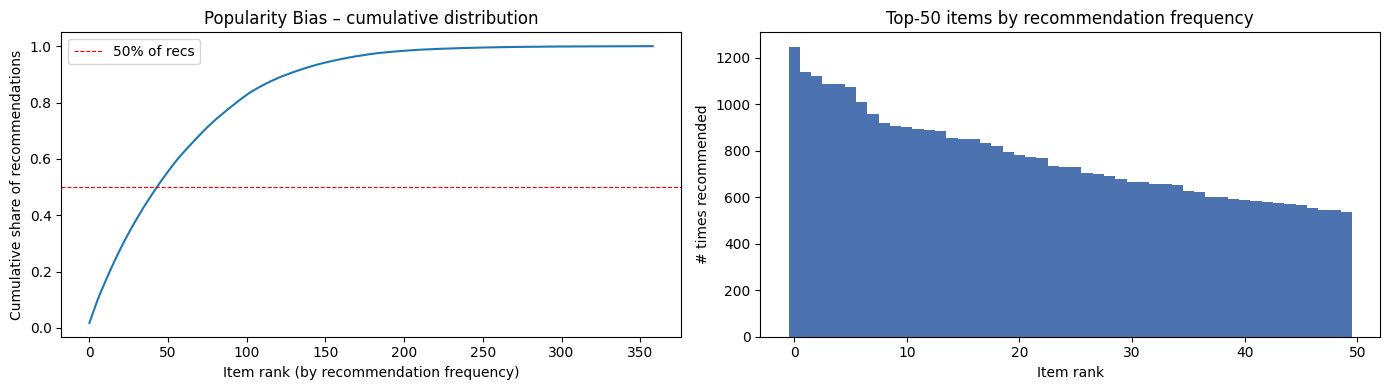

Top-44 items account for 50% of all recommendations out of 359 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_18819583,1246,28667,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,2.113202
nfmcg_19023598,1136,137356,Electronic Devices and Gadgets,Portable Electronics,3.917161
nfmcg_28005933,1120,28667,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,4.155153
nfmcg_21195272,1088,137356,None,None,4.871610
nfmcg_6755174,1087,137356,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,6.277985
nfmcg_2951017,1074,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,8.256651
nfmcg_22207127,1010,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,6.621515
nfmcg_23458271,958,137356,Household Electrical Appliances,Smart Home Systems,-1.258009
nfmcg_13962039,919,28667,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.362268
nfmcg_8010371,906,211031,Foodstuffs and Beverages,Sweet Desserts and Confectionery,-0.739520


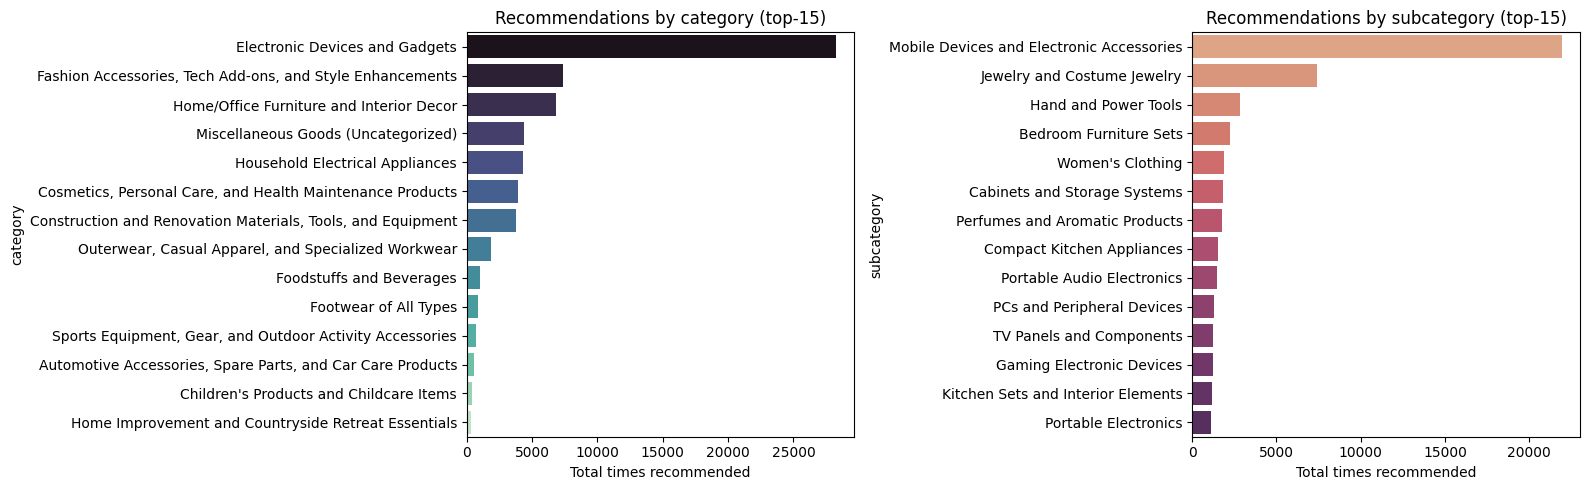

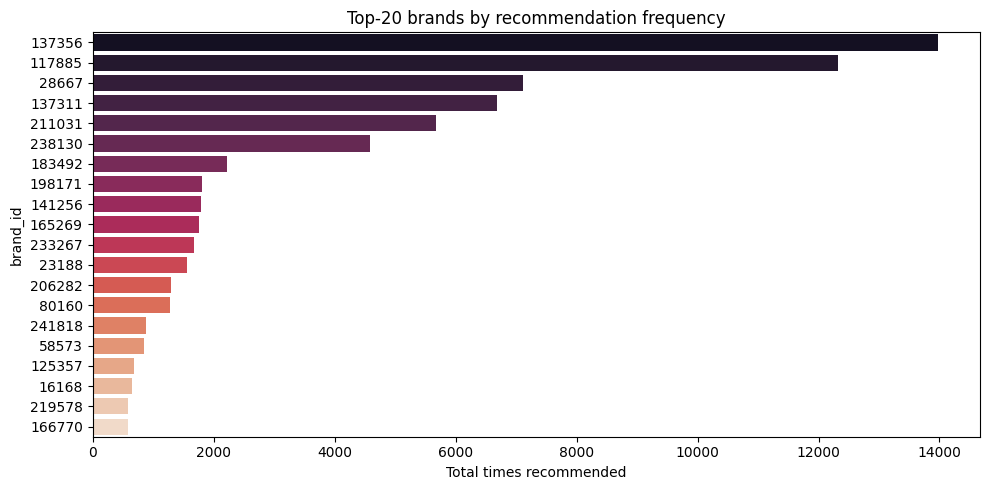

In [50]:
explore_recommendations(model_recommendations)

#### Confidence (1p)

Поэкспериментируйте с confidence-матрицей. Например, можно взвесить `label` в зависимости от `timestamp` или сделать `label` небинарным на основе `action_type`. Также можно взвесить `label` в зависимости от поверхности `subdomain`. 

Обучите iALS. Сделайте выводы.

In [51]:
class iALSRecommenderWeighted(BaseMFRecommender):
    """
    iALS with a custom confidence matrix:
      confidence = alpha * label_weight * time_weight
    where:
      label_weight = pos_weight if label==1 else 1.0   (positives matter more)
      time_weight  = linear decay: newer events -> weight closer to 1, older -> closer to 0
    """
    def __init__(self, factors=64, iterations=15, regularization=0.01,
                 alpha=10.0, pos_weight=5.0):
        super().__init__(name="ials_weighted")
        self.model = AlternatingLeastSquares(
            factors=factors,
            iterations=iterations,
            regularization=regularization,
            random_state=42,
        )
        self.alpha = alpha
        self.pos_weight = pos_weight

    def _fit(self, interactions: pl.DataFrame):
        ts = interactions["timestamp"].cast(pl.Int64).to_numpy().astype(np.float64)
        ts_min, ts_max = ts.min(), ts.max()
        time_weight = (ts - ts_min) / (ts_max - ts_min + 1e-9)

        labels = interactions["label"].to_numpy().astype(np.float32)
        label_weight = np.where(labels == 1, self.pos_weight, 1.0)
        confidence = (self.alpha * label_weight * time_weight).astype(np.float32)

        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()

        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}

        rows = [self.user2id[u] for u in interactions[self.user_col]]
        cols = [self.item2id[i] for i in interactions[self.item_col]]

        self.interactions_matrix = csr_matrix(
            (confidence, (rows, cols)),
            shape=(len(unique_users), len(unique_items)),
            dtype=np.float32,
        )

        self.model.fit(self.interactions_matrix)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        row_ids = np.array([self.user2id[u] for u in user_ids if u in self.user2id])
        item_indices, _ = self.model.recommend(
            row_ids,
            self.interactions_matrix[row_ids],
            N=topn,
            filter_already_liked_items=True,
        )
        return [[self.id2item[i] for i in row] for row in item_indices]



gt_val = dict(zip(
    val_events["user_id"].to_list(),
    [set(items) for items in val_events["item_id"].to_list()],
))

In [53]:
BEST_FACTORS = 32     
BEST_REG     = 0.1
BEST_ALPHA   = 1.0

experiments = [
    iALSRecommender(factors=BEST_FACTORS, regularization=BEST_REG, alpha=BEST_ALPHA),
    iALSRecommenderWeighted(factors=BEST_FACTORS, regularization=BEST_REG,
                            alpha=BEST_ALPHA, pos_weight=2.0),
    iALSRecommenderWeighted(factors=BEST_FACTORS, regularization=BEST_REG,
                            alpha=BEST_ALPHA, pos_weight=5.0),
    iALSRecommenderWeighted(factors=BEST_FACTORS, regularization=BEST_REG,
                            alpha=BEST_ALPHA, pos_weight=10.0),
]

exp_results = []
for m in experiments:
    t0 = time.perf_counter()
    m.fit(train_events)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    recs = m.recommend(val_users, topn=N)
    inf_time = time.perf_counter() - t0

    recs_dict = dict(zip(val_users, recs))
    label = m.name + (f"  pos_w={m.pos_weight}" if hasattr(m, "pos_weight") else "")
    exp_results.append({
        "model"        : label,
        "fit_sec"      : round(fit_time, 2),
        "inference_sec": round(inf_time, 3),
        "hit_rate"     : round(hit_rate(recs_dict, gt_val, k=N), 4),
        "recall"       : round(recall(recs_dict, gt_val, k=N), 4),
        "ndcg"         : round(ndcg(recs_dict, gt_val, k=N), 4),
        "coverage"     : round(coverage(recs, catalog_size=CATALOG_SIZE, k=N), 4),
    })
    print(exp_results[-1])

exp_df = pd.DataFrame(exp_results).sort_values("ndcg", ascending=False)
exp_df.style.format(precision=4).background_gradient(cmap="Blues")

  0%|          | 0/15 [00:00<?, ?it/s]

{'model': 'ials', 'fit_sec': 1.0, 'inference_sec': 0.028, 'hit_rate': 0.2326, 'recall': np.float64(0.0617), 'ndcg': np.float64(0.0364), 'coverage': 0.0001}


  0%|          | 0/15 [00:00<?, ?it/s]

{'model': 'ials_weighted  pos_w=2.0', 'fit_sec': 0.97, 'inference_sec': 0.019, 'hit_rate': 0.2583, 'recall': np.float64(0.068), 'ndcg': np.float64(0.0411), 'coverage': 0.0003}


  0%|          | 0/15 [00:00<?, ?it/s]

{'model': 'ials_weighted  pos_w=5.0', 'fit_sec': 0.67, 'inference_sec': 0.02, 'hit_rate': 0.3043, 'recall': np.float64(0.0841), 'ndcg': np.float64(0.0506), 'coverage': 0.0003}


  0%|          | 0/15 [00:00<?, ?it/s]

{'model': 'ials_weighted  pos_w=10.0', 'fit_sec': 0.69, 'inference_sec': 0.02, 'hit_rate': 0.3141, 'recall': np.float64(0.0897), 'ndcg': np.float64(0.0569), 'coverage': 0.0003}


,model,fit_sec,inference_sec,hit_rate,recall,ndcg,coverage
3,ials_weighted pos_w=10.0,0.6900,0.0200,0.3141,0.0897,0.0569,0.0003
2,ials_weighted pos_w=5.0,0.6700,0.0200,0.3043,0.0841,0.0506,0.0003
1,ials_weighted pos_w=2.0,0.9700,0.0190,0.2583,0.0680,0.0411,0.0003
0,ials,1.0000,0.0280,0.2326,0.0617,0.0364,0.0001


In [54]:
best_pos_weight = 10
best_weighted = iALSRecommenderWeighted(
    factors=BEST_FACTORS, regularization=BEST_REG,
    alpha=BEST_ALPHA, pos_weight=best_pos_weight,
)


t0 = time.perf_counter()
best_weighted.fit(train_val_events)
print(f"\nRetrain on train+val: {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
model_recommendations = best_weighted.recommend(test_users, topn=N)
print(f"Inference on test:    {time.perf_counter() - t0:.2f}s")

test_events = test_events.with_columns(
    pl.Series(model_recommendations).alias(best_weighted.name)
)

RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(
        evaluate(test_events, recommendations_column=best_weighted.name),
        index=[best_weighted.name],
    ),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

  0%|          | 0/15 [00:00<?, ?it/s]


Retrain on train+val: 0.9s
Inference on test:    0.03s


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005
ials,0.06630,0.01195,0.01587,0.00008,0.12546,0.02251,0.01903,0.00011,0.22149,0.04133,0.02621,0.00015
ials_weighted,0.12318,0.02125,0.03135,0.00016,0.19263,0.03453,0.03309,0.00022,0.28894,0.05715,0.04091,0.00031


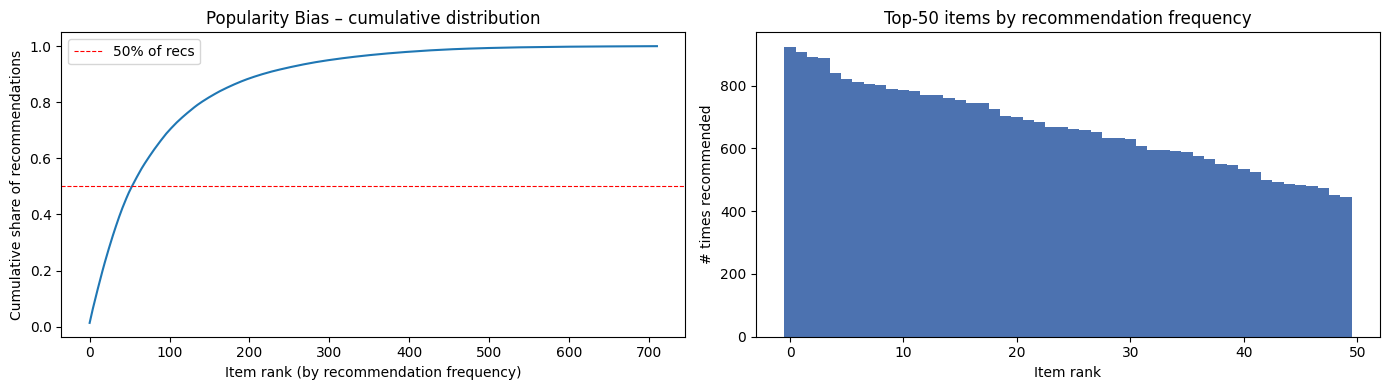

Top-54 items account for 50% of all recommendations out of 711 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_17273308,924,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,6.379223
nfmcg_10130954,907,137356,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,4.511980
nfmcg_716576,892,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,8.020088
nfmcg_8957656,888,80160,Miscellaneous Goods (Uncategorized),None,0.786800
nfmcg_8797298,840,137356,Miscellaneous Goods (Uncategorized),None,4.558963
nfmcg_13647154,822,23188,Household Electrical Appliances,Home Appliances,6.532209
nfmcg_18954296,812,183492,None,None,-2.211777
nfmcg_12977198,807,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.725761
nfmcg_21503632,802,211031,Miscellaneous Goods (Uncategorized),None,1.947144
nfmcg_25928977,791,238130,Home/Office Furniture and Interior Decor,Cabinets and Storage Systems,5.609664


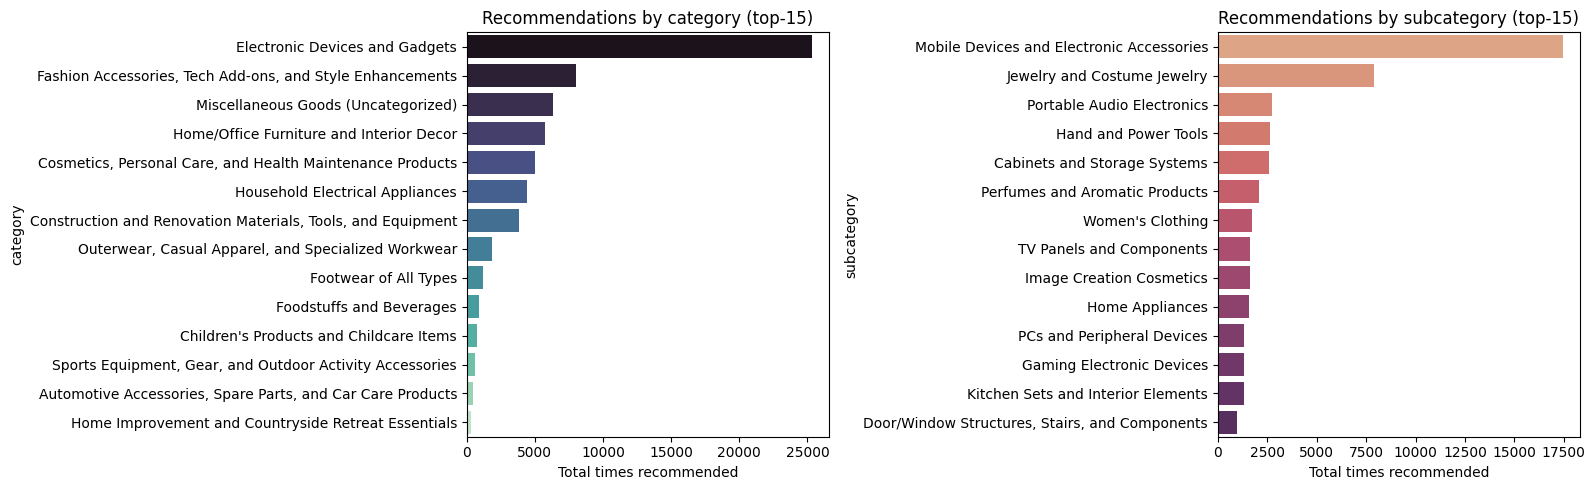

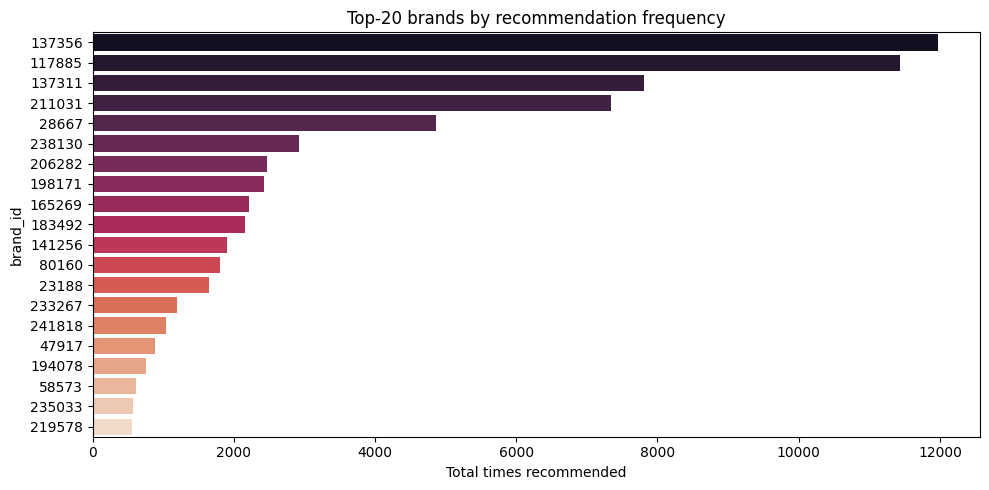

In [55]:
explore_recommendations(model_recommendations)


>Как видно из таблицы - взвешивание значительно улучшило наши метрики. Лучший результат с весом = 10. 

### iALS+ANN (1p)

#### FaissModel (0.5p)

Напишите iALSANNRecommender, который будет использовать FaissModel (тоже из `implicit`) поверх AlternatingLeastSquares для ускорения процесса рекомендаций. 

Оцените метрики качества и время работы в сравнении с AlternatingLeastSquares. Опишите результаты. Когда использование ANN может быть оправдано?

In [56]:
class iALSANNRecommender(iALSRecommender):

    def __init__(self, factors=64, iterations=15, regularization=0.01,
                 alpha=1.0, nlist=100, nprobe=10):
        super().__init__(factors=factors, iterations=iterations,
                         regularization=regularization, alpha=alpha,)  
        self.name = "ials_ann_faiss"
        self.nlist  = nlist
        self.nprobe = nprobe
        self.ann_model = None

    def _fit(self, interactions: pl.DataFrame):
        super()._fit(interactions)  
        self.ann_model = FaissModel(
            self.model,
            approximate_similar_items=False,
            approximate_recommend=True,
            nlist=self.nlist,
            nprobe=self.nprobe,
            use_gpu=False,
        )
        self.ann_model.fit(self.interactions_matrix)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        row_ids = np.array([self.user2id[u] for u in user_ids if u in self.user2id])
        user_items = self.interactions_matrix[row_ids]

        # filter_already_liked_items=True triggers np.in1d which is removed in NumPy 2.0
        # so we request extra candidates and filter seen items manually
        item_indices, _ = self.ann_model.recommend(
            row_ids,
            user_items,
            N=topn + user_items.shape[1],  # extra budget to compensate for filtering
            filter_already_liked_items=False,
        )

        results = []
        for i, row in enumerate(item_indices):
            seen = set(user_items[i].indices)  # items this user interacted with
            filtered = [idx for idx in row if idx not in seen][:topn]
            results.append([self.id2item[idx] for idx in filtered])
        return results





In [57]:
model = iALSANNRecommender(
    factors=BEST_FACTORS, regularization=BEST_REG, alpha=BEST_ALPHA,
    nlist=100, nprobe=10,
)

In [58]:
%%time
model.fit(train_val_events)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

CPU times: user 1.3 s, sys: 8.82 ms, total: 1.31 s
Wall time: 1.27 s


In [59]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 19.3 s, sys: 1.38 s, total: 20.7 s
Wall time: 14.9 s


In [60]:
test_events = test_events.with_columns(
    pl.Series(model_recommendations).alias(model.name)
)

RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(
        evaluate(test_events, recommendations_column=model.name),
        index=[model.name],
    ),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005
ials,0.06630,0.01195,0.01587,0.00008,0.12546,0.02251,0.01903,0.00011,0.22149,0.04133,0.02621,0.00015
ials_weighted,0.12318,0.02125,0.03135,0.00016,0.19263,0.03453,0.03309,0.00022,0.28894,0.05715,0.04091,0.00031
ials_ann_faiss,0.06888,0.01096,0.01768,0.00018,0.09774,0.01615,0.01693,0.00032,0.13061,0.02283,0.01856,0.00062


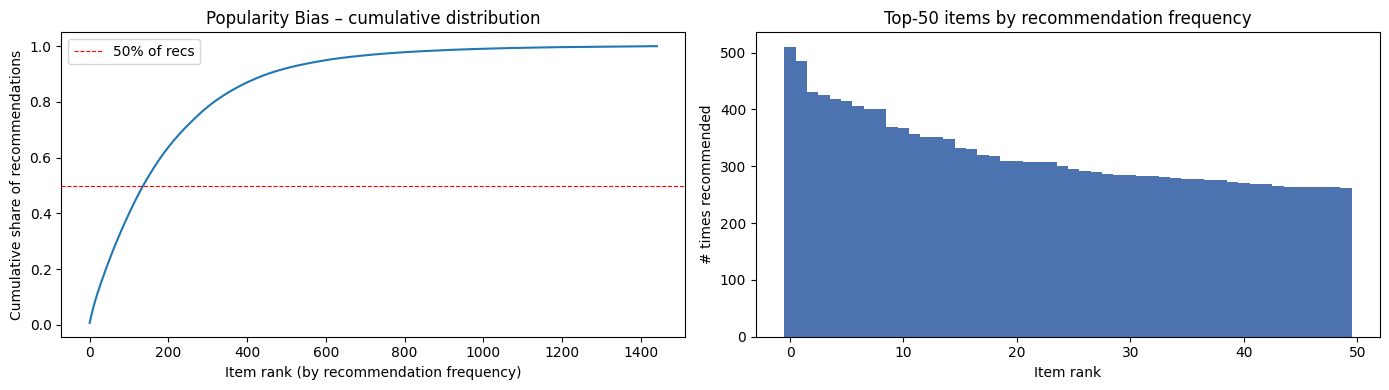

Top-137 items account for 50% of all recommendations out of 1,442 unique items recommended

── Top-10 most recommended items ──


item_id,rec_count,brand_id,category,subcategory,price
nfmcg_18084908,510,137311,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry,3.849199
nfmcg_39238,485,238130,Home/Office Furniture and Interior Decor,Cabinets and Storage Systems,3.525763
nfmcg_21840060,430,125357,"Outerwear, Casual Apparel, and Specialized Workwear",Women's Clothing,-0.258433
nfmcg_6301488,426,183492,"Outerwear, Casual Apparel, and Specialized Workwear",Women's Clothing,-0.688387
nfmcg_19395384,419,211031,"Cosmetics, Personal Care, and Health Maintenance Products",Facial Cosmetics and Care Products,-0.738158
nfmcg_7088829,414,183492,None,None,-0.886092
nfmcg_22274857,406,23188,Miscellaneous Goods (Uncategorized),None,3.773678
nfmcg_12646018,401,28667,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.937366
nfmcg_14925223,400,198171,Home/Office Furniture and Interior Decor,Kitchen Sets and Interior Elements,1.887035
nfmcg_27347379,369,183492,"Outerwear, Casual Apparel, and Specialized Workwear",Women's Clothing,-2.096139


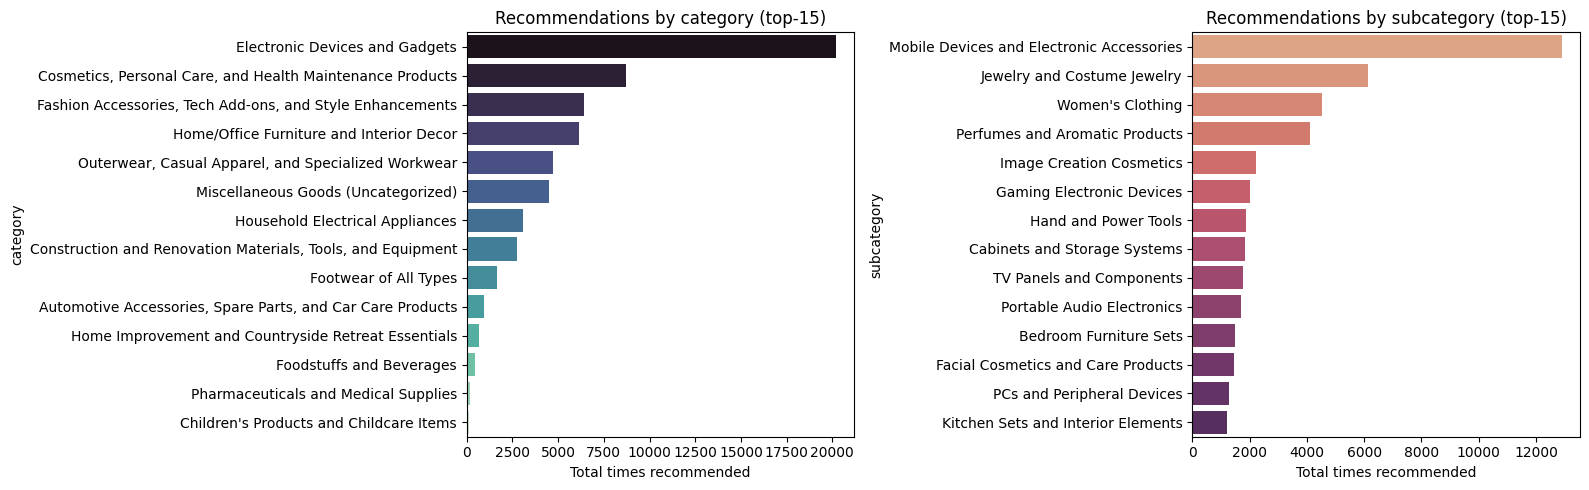

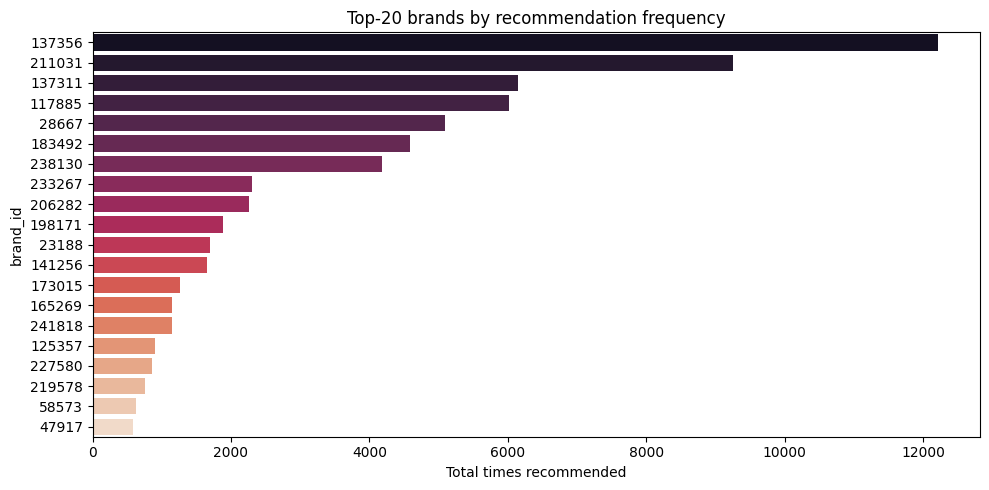

In [61]:
explore_recommendations(model_recommendations)

In [62]:
train_val_events['item_id'].unique().shape

(27162,)

ANN оправдан когда **каталог большой** (от ~500k–1M айтемов) и важен быстрый онлайн-инференс.

При точном поиске сложность — O(n_items × factors) на каждого пользователя. При миллионе айтемов и factors=128 это уже ~10⁸ операций на запрос, что слишком медленно для realtime. Faiss ускоряет вычисления практически в 10-100 раз

**На нашем датасете (30k айтемов) ANN бессмысленен** — точный поиск и так работает за миллисекунды, а накладные расходы на построение индекса и приближённый поиск только добавляют сложность без выигрыша.

#### Item2item (0.5p)

Отвлечемся от user2item рекомендации и посмотрим в сторону item2item ("похожие товары"). Сначала взглянем, насколько похожие айтемы выдает ANN с предыдущего шага.

In [63]:
# код можно адаптировать, если у вас иная реализация
# и айдишник айтема можно менять - посмотрите-потыкайтесь
HTML(
    ITEMS.filter(
        pl.col("item_id").is_in(
            [model.id2item[idx] for idx in model.ann_model.similar_items(model.item2id["nfmcg_6755174"])[0]]
        )
    )
    .select("item_id", "category", "subcategory")
    .to_pandas().to_html()
)

,item_id,category,subcategory
0,nfmcg_1163229,None,None
1,nfmcg_13393367,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
2,nfmcg_15908423,"Fashion Accessories, Tech Add-ons, and Style Enhancements","Bags, Backpacks, and Travel Accessories"
3,nfmcg_16127498,"Fashion Accessories, Tech Add-ons, and Style Enhancements","Bags, Backpacks, and Travel Accessories"
4,nfmcg_17045356,Miscellaneous Goods (Uncategorized),None
5,nfmcg_20883182,"Fashion Accessories, Tech Add-ons, and Style Enhancements","Bags, Backpacks, and Travel Accessories"
6,nfmcg_21400721,None,None
7,nfmcg_21922941,"Fashion Accessories, Tech Add-ons, and Style Enhancements","Bags, Backpacks, and Travel Accessories"
8,nfmcg_23876687,None,None
9,nfmcg_6755174,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories


Теперь поработаем с теми айтемами из каталога, у которых присутствует категория (можно и без категории, но вряд ли по null будет сильно понятно, что это за айтем).

In [64]:
items_with_categories = (
    ITEMS.filter(pl.col("subcategory").is_not_null()).select("item_id", "category", "subcategory", "embedding").with_row_index()
)
items_with_categories

index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
0,"""nfmcg_1000002""","""Fashion Accessories, Tech Add-…","""Hats, Scarves, and Shawls""","[-0.056533, 0.082878, … 0.037475]"
1,"""nfmcg_10000039""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.157201, 0.026234, … 0.013904]"
2,"""nfmcg_10000085""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.124708, 0.037677, … -0.017627]"
3,"""nfmcg_10000098""","""Fashion Accessories, Tech Add-…","""Bags, Backpacks, and Travel Ac…","[-0.085646, 0.032929, … 0.069084]"
4,"""nfmcg_10000100""","""Cosmetics, Personal Care, and …","""Dental and Gum Hygiene Product…","[-0.05772, 0.081778, … 0.034646]"
…,…,…,…,…
1092381,"""nfmcg_9999917""","""Pharmaceuticals and Medical Su…","""Dietary Supplements and Vitami…","[-0.041579, 0.028325, … 0.068679]"
1092382,"""nfmcg_999993""","""Outerwear, Casual Apparel, and…","""Men's Clothing""","[-0.038017, 0.05173, … 0.097221]"
1092383,"""nfmcg_9999949""","""Outerwear, Casual Apparel, and…","""Women's Clothing""","[-0.097365, 0.038201, … 0.030096]"


Обучите FAISS-индекс на эмбеддингах айтемов. Придется немного покопаться в документации https://github.com/facebookresearch/faiss, но решение должно занять около 5 строчек кода. 

В примере ниже использовался тип индекса "IVF256_HNSW32,Flat". 

In [65]:
embeddings = np.vstack(items_with_categories["embedding"].to_numpy()).astype(np.float32)
d = embeddings.shape[1]  # 300
index = faiss.index_factory(d, "IVF256_HNSW32,Flat")
index.train(embeddings)
index.add(embeddings)
index.nprobe = 16  
print(f"Index built: {index.ntotal:,} vectors, d={d}")

Index built: 1,092,386 vectors, d=300


In [66]:
%%time
distances, indices = index.search(items_with_categories.filter(pl.col("item_id").eq("nfmcg_6755174"))["embedding"].to_numpy(), 10)
items_with_categories.filter(pl.col("index").is_in(indices.flatten()))

CPU times: user 37.4 ms, sys: 5.23 ms, total: 42.6 ms
Wall time: 41.7 ms


index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
33807,"""nfmcg_1078940""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091484, 0.049256, … 0.041291]"
108090,"""nfmcg_12551464""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083419, 0.047695, … 0.048635]"
288831,"""nfmcg_16815234""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.086212, 0.031782, … 0.065634]"
321776,"""nfmcg_17600235""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.070968, 0.038067, … 0.052249]"
558311,"""nfmcg_23178267""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.085651, 0.035771, … 0.040709]"
788302,"""nfmcg_2858251""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.089298, 0.038707, … 0.043044]"
954950,"""nfmcg_6755174""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.07863, 0.045097, … 0.052823]"
1013775,"""nfmcg_8139701""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091742, 0.052721, … 0.043532]"
1021323,"""nfmcg_8317031""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083585, 0.034589, … 0.058617]"


Кстати, вместо ANN можно попробовать использовать честный kNN, но, учитывая размеры каталога, это будет долго и вероятно убьет RAM.

## NeuMF (1.5p)

На основе материалов семинара реализуйте NeuMF. Оцените качество и сравните с остальными моделями.

Часть с обучением продублирована из кода семинара, вы можете изменять её, а также подобрать гиперпараметры. Попробуйте добиться сопоставимого с предыдущими моделями качества. Опишите сделанные изменения и результаты экспериментов.

In [67]:
unique_users = train_val_events["user_id"].unique()
unique_items = train_val_events["item_id"].unique()

id2user = dict(enumerate(unique_users))
id2item = dict(enumerate(unique_items))

user2id = {v: k for k, v in id2user.items()}
item2id = {v: k for k, v in id2item.items()}

In [68]:
print(len(unique_users), len(unique_items))

9613 27162


In [69]:
train_df = (
    train_val_events
    .filter(pl.col("label") > 0)
    .with_columns(
        user_id_encoded=pl.col("user_id").replace(user2id).cast(pl.Int32), 
        item_id_encoded=pl.col("item_id").replace(item2id).cast(pl.Int32)
    )
)

user_interactions = dict(
    train_df.group_by("user_id_encoded").agg(pl.col("item_id_encoded")).iter_rows()
)  # encoded_user_id: list[encoded_item_id]

In [70]:
train_encoded_users = torch.Tensor(train_df["user_id_encoded"]).long()
train_encoded_items = torch.Tensor(train_df["item_id_encoded"]).long()

In [77]:
class NeuMF(nn.Module):
    def __init__(
        self,
        n_users: int,
        m_items: int,
        n_factors: int,
        hidden_dim: int,
        dropout : int
    ) -> None:
        super().__init__()
        self.name = "NeuMF"

        self.m_items = m_items

        # Embeddings for GMF
        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(m_items, n_factors)

        # Embeddings for MLP
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(m_items, n_factors)

        # MLP tower
        self.mlp = nn.Sequential(
            nn.Linear(2 * n_factors, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Final prediction layer
        self.out = nn.Linear(
            n_factors + hidden_dim // 2, 1
        )

        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.user_emb_gmf,
            self.item_emb_gmf,
            self.user_emb_mlp,
            self.item_emb_mlp,
        ]:
            nn.init.normal_(emb.weight, std=0.01)

        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, item: torch.Tensor, user: torch.Tensor) -> torch.Tensor:
        """
        item, user: LongTensor of shape (batch,)
        """

        # --- GMF part ---
        u_gmf = self.user_emb_gmf(user)      # (B, k)
        i_gmf = self.item_emb_gmf(item)      # (B, k)
        gmf = u_gmf * i_gmf                  # element-wise product

        # --- MLP part ---
        u_mlp = self.user_emb_mlp(user)      # (B, k)
        i_mlp = self.item_emb_mlp(item)      # (B, k)
        mlp_input = torch.cat([u_mlp, i_mlp], dim=-1)
        mlp_out = self.mlp(mlp_input)        # (B, hidden//2)

        # --- Fusion ---
        x = torch.cat([gmf, mlp_out], dim=-1)
        prediction = self.out(x).squeeze(-1)  # (B,)

        return prediction

In [ ]:
from IPython.display import display as ipy_display, clear_output



def train_neumf(
    # data
    train_encoded_users: torch.Tensor,
    train_encoded_items: torch.Tensor,
    val_events: pl.DataFrame,          
    user2id: dict,
    item2id: dict,
    id2item: dict,
    # architecture
    n_factors:  int   = 64,
    hidden_dim: int   = 128,
    dropout:    float = 0.2,
    # training
    lr:         float = 1e-3,
    weight_decay: float = 1e-5,
    batch_size: int   = 1024,
    num_epochs: int   = 10,
) -> tuple[NeuMF, list[list]]:
    """
    Train NeuMF and return (fitted model, test recommendations).
    Plots live train/val loss curve after each epoch.
    """
    device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_users     = len(user2id)
    m_items     = len(item2id)
    all_items   = np.arange(m_items)

    model     = NeuMF(n_users, m_items, n_factors, hidden_dim, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    loss_fn   = nn.BCEWithLogitsLoss()

    # ── Val tensors ──────────────────────────────────────────────────────────
    val_u, val_i = [], []
    for row in val_events.iter_rows(named=True):
        uid = row["user_id"]
        if uid not in user2id:
            continue
        for iid in row["item_id"]:
            if iid in item2id:
                val_u.append(user2id[uid])
                val_i.append(item2id[iid])
    val_u = torch.tensor(val_u, dtype=torch.long)
    val_i = torch.tensor(val_i, dtype=torch.long)

    # ── Helpers ──────────────────────────────────────────────────────────────
    def run_epoch(users, items, train: bool) -> float:
        model.train(train)
        losses, ctx = [], torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for start in range(0, len(users), batch_size):
                bu  = users[start:start + batch_size].to(device)
                bi  = items[start:start + batch_size].to(device)
                neg = torch.from_numpy(np.random.choice(all_items, len(bu))).long().to(device)

                pos_pred = model(bi,  bu)
                neg_pred = model(neg, bu)
                loss = loss_fn(pos_pred, torch.ones_like(pos_pred)) + \
                       loss_fn(neg_pred, torch.zeros_like(neg_pred))

                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

                losses.append(loss.item())
        return float(np.mean(losses))

    def plot(train_losses, val_losses):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4))
        epochs = range(1, len(train_losses) + 1)
        ax.plot(epochs, train_losses, marker="o", label="train")
        ax.plot(epochs, val_losses,   marker="s", label="val")
        ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
        ax.set_title("NeuMF — Train vs Val Loss")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        ipy_display(fig)
        plt.close(fig)

    # ── Training loop ─────────────────────────────────────────────────────────
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        perm           = torch.randperm(len(train_encoded_users))
        train_loss     = run_epoch(train_encoded_users[perm],
                                   train_encoded_items[perm], train=True)
        val_loss       = run_epoch(val_u, val_i, train=False)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        plot(train_losses, val_losses)
        print(f"Epoch {epoch+1}/{num_epochs}  "
              f"train={train_loss:.4f}  val={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

    # ── Inference ─────────────────────────────────────────────────────────────
    model.eval()
    all_item_tensor = torch.arange(m_items, device=device)
    recommendations = []
    with torch.no_grad():
        for uid in test_users:
            if uid not in user2id:
                recommendations.append([])
                continue
            u_enc  = torch.full((m_items,), user2id[uid], dtype=torch.long, device=device)
            scores = model(all_item_tensor, u_enc).cpu().numpy()
            top    = np.argpartition(scores, -N)[-N:]
            top    = top[np.argsort(scores[top])[::-1]]
            recommendations.append([id2item[i] for i in top])

    return model, recommendations


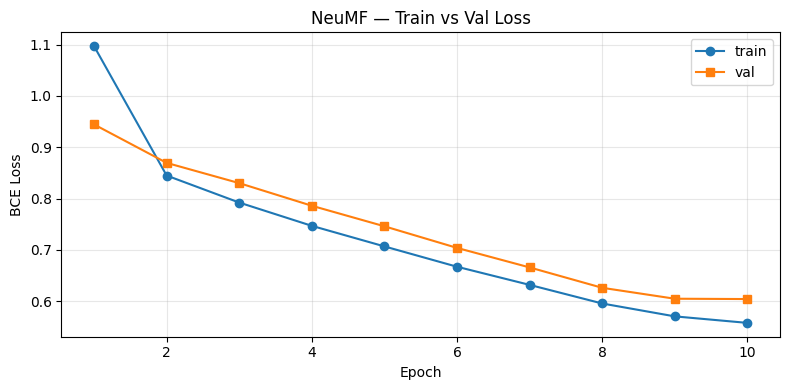

Epoch 10/10  train=0.5575  val=0.6039  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001


In [ ]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 64,
    hidden_dim          = 128,
    dropout             = 0.2,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 1024,
    num_epochs          = 10,
)


test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.DataFrame()
NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=["n_factors=64, batch=1024, epochs=10"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")


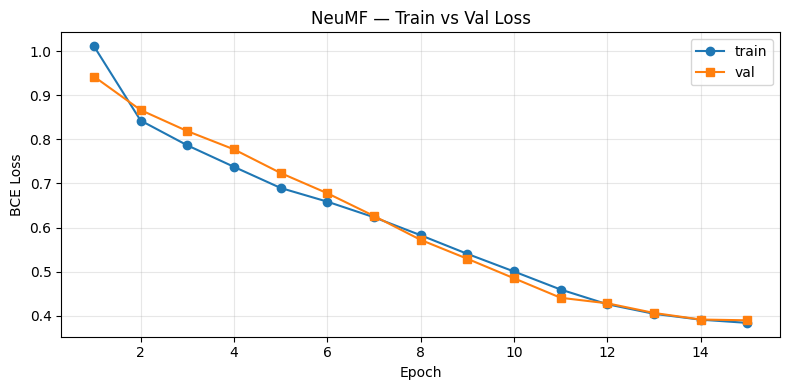

Epoch 15/15  train=0.3842  val=0.3901  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001
"n_factors=64, batch=512, epochs=15",0.12232,0.02179,0.02783,0.00000,0.22349,0.04251,0.03425,0.00001,0.45699,0.10245,0.05699,0.00001


In [89]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 64,
    hidden_dim          = 128,
    dropout             = 0.2,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 512,
    num_epochs          = 15,
)

test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=["n_factors=64, batch=512, epochs=15"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

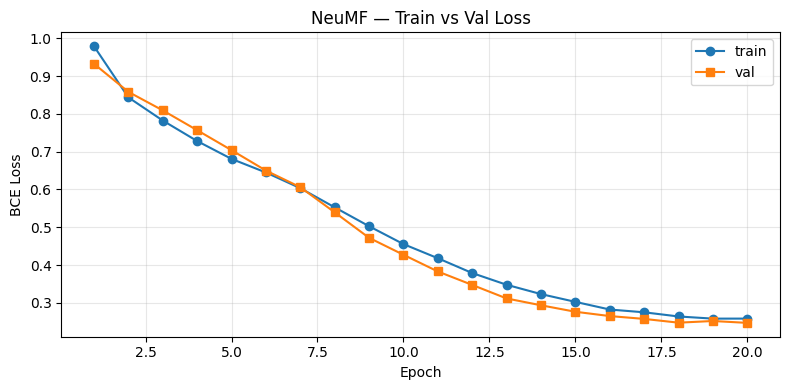

Epoch 20/20  train=0.2582  val=0.2469  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001
"n_factors=64, batch=512, epochs=15",0.12232,0.02179,0.02783,0.00000,0.22349,0.04251,0.03425,0.00001,0.45699,0.10245,0.05699,0.00001
"n_factors=64, batch=256, epochs=20 dropout=0.25",0.12861,0.02287,0.03230,0.00000,0.18520,0.03233,0.03198,0.00001,0.44984,0.10036,0.05821,0.00002


In [90]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 64,
    hidden_dim          = 128,
    dropout             = 0.25,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 256,
    num_epochs          = 20,
)

test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=[f"n_factors=64, batch=256, epochs=20 dropout=0.25"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

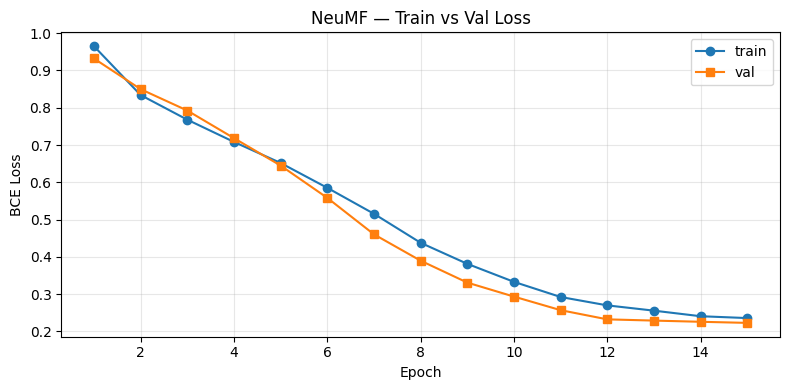

Epoch 15/15  train=0.2357  val=0.2228  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001
"n_factors=64, batch=512, epochs=15",0.12232,0.02179,0.02783,0.00000,0.22349,0.04251,0.03425,0.00001,0.45699,0.10245,0.05699,0.00001
"n_factors=64, batch=256, epochs=20 dropout=0.25",0.12861,0.02287,0.03230,0.00000,0.18520,0.03233,0.03198,0.00001,0.44984,0.10036,0.05821,0.00002
"n_factors=128 hid = 256 batch=256, epochs=15 dropout=0.3",0.12889,0.02290,0.02324,0.00000,0.25664,0.04930,0.03332,0.00003,0.45413,0.10393,0.05455,0.00019


In [91]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 128,
    hidden_dim          = 256,
    dropout             = 0.3,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 256,
    num_epochs          = 15,
)

test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=[f"n_factors=128 hid = 256 batch=256, epochs=15 dropout=0.3"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

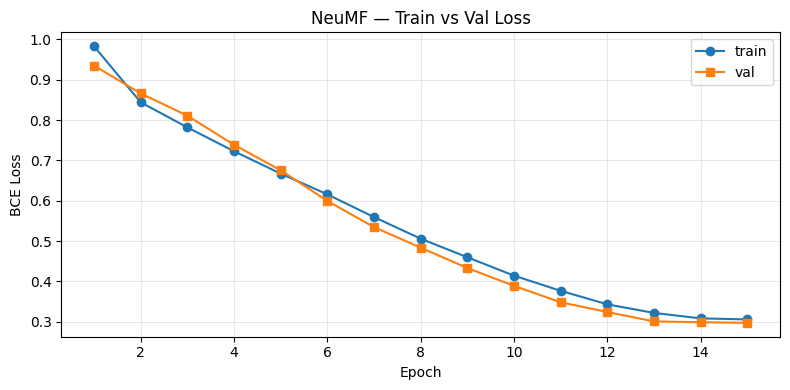

Epoch 15/15  train=0.3056  val=0.2970  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001
"n_factors=64, batch=512, epochs=15",0.12232,0.02179,0.02783,0.00000,0.22349,0.04251,0.03425,0.00001,0.45699,0.10245,0.05699,0.00001
"n_factors=64, batch=256, epochs=20 dropout=0.25",0.12861,0.02287,0.03230,0.00000,0.18520,0.03233,0.03198,0.00001,0.44984,0.10036,0.05821,0.00002
"n_factors=128 hid = 256 batch=256, epochs=15 dropout=0.3",0.12889,0.02290,0.02324,0.00000,0.25664,0.04930,0.03332,0.00003,0.45413,0.10393,0.05455,0.00019
"n_factors=128 hid = 256 batch=512, epochs=15 dropout=0.3",0.12861,0.02287,0.02678,0.00000,0.15890,0.02972,0.02530,0.00001,0.44527,0.09998,0.05386,0.00002


In [92]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 128,
    hidden_dim          = 256,
    dropout             = 0.3,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 512,
    num_epochs          = 15,
)

test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=[f"n_factors=128 hid = 256 batch=512, epochs=15 dropout=0.3"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

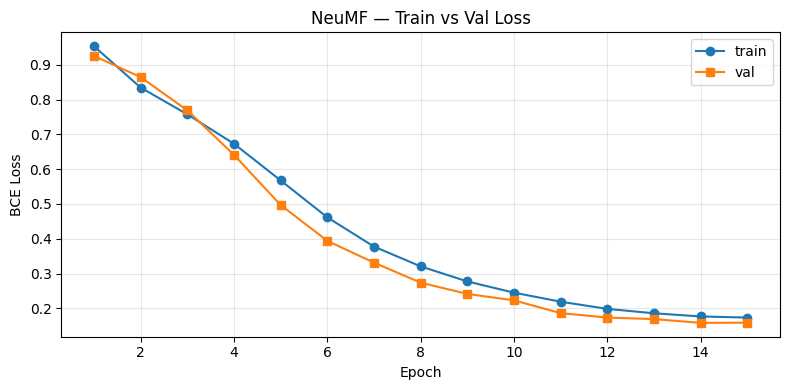

Epoch 15/15  train=0.1737  val=0.1590  lr=0.00e+00


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
"n_factors=64, batch=1024, epochs=10",0.12861,0.02287,0.02528,0.00000,0.18177,0.03227,0.02583,0.00000,0.44584,0.09866,0.05124,0.00001
"n_factors=64, batch=512, epochs=15",0.12232,0.02179,0.02783,0.00000,0.22349,0.04251,0.03425,0.00001,0.45699,0.10245,0.05699,0.00001
"n_factors=64, batch=256, epochs=20 dropout=0.25",0.12861,0.02287,0.03230,0.00000,0.18520,0.03233,0.03198,0.00001,0.44984,0.10036,0.05821,0.00002
"n_factors=128 hid = 256 batch=256, epochs=15 dropout=0.3",0.12889,0.02290,0.02324,0.00000,0.25664,0.04930,0.03332,0.00003,0.45413,0.10393,0.05455,0.00019
"n_factors=128 hid = 256 batch=512, epochs=15 dropout=0.3",0.12861,0.02287,0.02678,0.00000,0.15890,0.02972,0.02530,0.00001,0.44527,0.09998,0.05386,0.00002
"n_factors=256 hid = 512 batch=256, epochs=15 dropout=0.3",0.12947,0.02313,0.03587,0.00039,0.20234,0.03903,0.03742,0.00114,0.44013,0.09609,0.05989,0.00232


In [93]:
model, model_recommendations = train_neumf(
    train_encoded_users = train_encoded_users,
    train_encoded_items = train_encoded_items,
    val_events          = val_events,
    user2id             = user2id,
    item2id             = item2id,
    id2item             = id2item,
    # architecture
    n_factors           = 256,
    hidden_dim          = 512,
    dropout             = 0.3,
    # training
    lr                  = 1e-3,
    weight_decay        = 1e-5,
    batch_size          = 256,
    num_epochs          = 15,
)

test_events = test_events.with_columns(pl.Series(model_recommendations).alias("NeuMF"))

NEUMF_RESULTS = pd.concat([
    NEUMF_RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column="NeuMF"),
                 index=[f"n_factors=256 hid = 512 batch=256, epochs=15 dropout=0.3"]),
])
NEUMF_RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

>Поэкспериментировал с различными гиперпараметрами, лучшие результаты дала НС с n_factors=256 hid = 512 batch=256, epochs=15 dropout=0.3

## Results (0.5p)

Опишите результаты, полученные в данной работе. Достаточно показать итоговую таблицу с метриками и проинтерпретировать полученные значения. Жалобы/предложения также принимаются :)

In [101]:
best_idx = NEUMF_RESULTS["ndcg@5"].idxmax() 
RESULTS = pd.concat([RESULTS, NEUMF_RESULTS.loc[[best_idx]].rename(index={best_idx: "NeuMF_best"})])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.73979,1.00000,0.00196,1.00000,0.91904,1.00000,0.00261,1.00000,0.98693,1.00000,0.00293
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005
ials,0.06630,0.01195,0.01587,0.00008,0.12546,0.02251,0.01903,0.00011,0.22149,0.04133,0.02621,0.00015
ials_weighted,0.12318,0.02125,0.03135,0.00016,0.19263,0.03453,0.03309,0.00022,0.28894,0.05715,0.04091,0.00031
ials_ann_faiss,0.06888,0.01096,0.01768,0.00018,0.09774,0.01615,0.01693,0.00032,0.13061,0.02283,0.01856,0.00062
NeuMF_best,0.12947,0.02313,0.03587,0.00039,0.20234,0.03903,0.03742,0.00114,0.44013,0.09609,0.05989,0.00232


In [102]:
RESULTS.drop('A/A').style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
random,0.00143,0.00028,0.00025,0.00556,0.00314,0.00048,0.00035,0.00848,0.00514,0.00065,0.00043,0.01078
toppop,0.12861,0.02287,0.03238,0.00000,0.16748,0.02878,0.02989,0.00000,0.45299,0.10110,0.05960,0.00001
socdem_toppop,0.15462,0.02790,0.03383,0.00001,0.29608,0.06055,0.04585,0.00003,0.46356,0.10994,0.06454,0.00005
ials,0.06630,0.01195,0.01587,0.00008,0.12546,0.02251,0.01903,0.00011,0.22149,0.04133,0.02621,0.00015
ials_weighted,0.12318,0.02125,0.03135,0.00016,0.19263,0.03453,0.03309,0.00022,0.28894,0.05715,0.04091,0.00031
ials_ann_faiss,0.06888,0.01096,0.01768,0.00018,0.09774,0.01615,0.01693,0.00032,0.13061,0.02283,0.01856,0.00062
NeuMF_best,0.12947,0.02313,0.03587,0.00039,0.20234,0.03903,0.03742,0.00114,0.44013,0.09609,0.05989,0.00232



**Выводы**

`socdem_toppop` — лучшая модель по большинству метрик. Это не удивительно: датасет небольшой (10k пользователей, 30k айтемов, всего 28 дней), паттерны потребления сильно коррелируют с соцдем-кластером, и топ-популярных айтемов внутри кластера уже даёт очень хороший сигнал.

**Почему `ials` хуже `toppop`?**

- **Мало данных для MF.** iALS учится на разреженной матрице взаимодействий. При 10k пользователей и коротком окне (20 дней train) большинство пользователей имеют 1–3 позитивных взаимодействия — эмбеддинги не успевают обучиться
- **coverage ≈ 0** у toppop/socdem_toppop — они рекомендуют одно и то же всем, и за счёт этого hits очень высокие. iALS персонализирует, но теряет в hit rate на коротком горизонте

**`ials_weighted` лучше `ials`** — временное взвешивание и upweighting позитивов помогают, но не перекрывают фундаментальную проблему разреженности.

**`ials_ann_faiss` хуже `ials`** — ANN теряет точность на маленьком каталоге (30k айтемов), где exact search и так быстрый. Приближение здесь только вредит.

**`NeuMF_best`** — хорош по ndcg@5 (лучше ials_weighted), но уступает socdem_toppop. При таком размере датасета нейронная сеть  не имеет достаточно данных чтобы выучить сложные паттерны поверх того, что даёт простая статистика популярности.

**coverage** — принципиальный trade-off: toppop/socdem_toppop имеют coverage ≈ 0 (рекомендуют 10–20 айтемов всем пользователям), NeuMF и iALS — на порядки выше. В продакшене нулевая coverage означает полное отсутствие разнообразия 

**Вывод:** на коротких временных окнах с небольшим числом взаимодействий простые popularity-based модели выигрывают у коллаборативной фильтрации. MF-модели начинают выигрывать когда данных много, окно длиннее, и метрика учитывает diversity/coverage.